# Context Replay: Overcoming Catastrophic Forgetting in Online Energy Demand Forecasting

**Anand Bhan Singh Chouhan** · M.Tech Software & Data Engineering  
Indian Institute of Information Technology Allahabad  
Supervisor: Prof. Dr. Sonali Agarwal

---

## Research Summary

Online energy demand forecasting models suffer **catastrophic forgetting** under **recurrent concept drift** — when the data stream cycles between Day and Night demand patterns, the model overwrites previously learned context knowledge. At each context re-entry, prediction errors spike before slowly recovering.

**Context Replay (CR)** solves this with two mechanisms:
1. **Dual-buffer architecture** — separate FIFO queues for Day (06:00–18:00) and Night (18:00–06:00) samples, each storing 200 recent observations
2. **Two-level replay** — continuous cross-context-heavy sampling (3 same + 7 opposite per step) + drift-gated warm-up bursts (16 samples at context switches near detected drift)

The total per-step replay budget (10 samples) and total buffer size (400 samples) are **identical** between CR and the FIFO baseline, isolating the contribution of context-aware partitioning.

### Models Evaluated
| # | Model | Type |
|---|---|---|
| 1 | LSTM (Static) | Deep learning baseline — trained once, no online adaptation |
| 2 | CapyMOA ARF | Online learning baseline — adapts continuously, no replay |
| 3 | ARF + FIFO Replay | Controlled baseline — unified replay buffer (10 samples/step, 200 buffer) |
| 4 | **ARF + Context Replay** | **Proposed** — Day/Night partitioned buffers (3+7 samples/step, 200×2 buffer) |

### Datasets
| Dataset | Country | Duration | Resolution |
|---|---|---|---|
| NESO Historic Demand | United Kingdom | 2 years | Hourly |
| UCI Electricity Load | Portugal | 2011–2014 | Hourly |
| AEMO NSW Demand | Australia | 2 years | Hourly |

### Hypotheses
- **H1:** Online learning (ARF) outperforms static LSTM after concept drift
- **H2:** Replay-augmented ARF outperforms plain ARF on forgetting metrics
- **H3:** Context-partitioned replay reduces context re-entry forgetting (CRFS) compared to naive FIFO replay

## Cell 1 — Install Dependencies

> **Run this cell alone first.**  
> When it prints `DONE`, click **Runtime → Restart session**.  
> Then run all remaining cells from Cell 2 onward. Do not run Cell 1 again.

In [2]:
import os
os.system("apt-get -qq update && apt-get -qq install -y --fix-missing default-jre-headless")
os.system("pip -q install --no-cache-dir 'numpy>=2.0,<2.1' 'pandas>=2.2' capymoa seaborn requests scipy")
print("DONE. Now: Runtime → Restart session → run from Cell 2.")

DONE. Now: Runtime → Restart session → run from Cell 2.


## Cell 2 — Imports & Global Seed

All libraries are imported here. The master seed (`SEED = 42`) is set across NumPy, Python `random`, and TensorFlow for full reproducibility. Individual experiments pass their own seed to model functions for multi-seed validation.

In [3]:
import os, re, io, time, random, zipfile, warnings, importlib
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import tensorflow as tf
from scipy.stats import wilcoxon

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from capymoa.stream import NumpyStream
from capymoa.regressor import AdaptiveRandomForestRegressor

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow : {tf.__version__}")
print(f"NumPy      : {np.__version__}")
print("Imports OK.")

TensorFlow : 2.19.0
NumPy      : 2.0.2
Imports OK.


## Cell 3 — Global Configuration

All hyperparameters are defined here in one place. Justification for each value:

| Parameter | Value | Rationale |
|---|---|---|
| `REPLAY_BUFFER_SIZE` | 200 per context | 400 samples total; matched exactly to FIFO for a fair memory comparison |
| `REPLAY_K_SAME` | 3 | Combined with `REPLAY_K_CROSS` for a total replay budget of 10, matched to FIFO |
| `REPLAY_K_CROSS` | 7 | Ensures the opposite context is continuously reinforced every step |
| `CTX_SWITCH_REPLAY_K` | 12 | ~2× the per-step budget; concentrated warm-up burst at high-risk moments |
| `DRIFT_MEMORY` | 48 | 2 days of hourly data; window during which a detected drift is considered active |
| `ADWIN_DELTA` | 0.002 | Low sensitivity — detects only significant distributional shifts |
| `ARF_TREES` | 20 | Standard ensemble size balancing accuracy and computational cost |

In [4]:
RUN_ROBUSTNESS = True
RUN_AEMO       = True

# ── Dataset ──────────────────────────────────────────────────────────────────
NESO_YEARS       = 2
NESO_MAX_SAMPLES = 12000
UCI_MAX_SAMPLES  = 8000
AEMO_MAX_SAMPLES = 18000

# ── Preprocessing ─────────────────────────────────────────────────────────────
TRAIN_RATIO  = 0.20
WINDOW_SIZE  = 24

# ── LSTM ──────────────────────────────────────────────────────────────────────
LSTM_EPOCHS_PRIMARY = 12
LSTM_EPOCHS_ROBUST  = 8
LSTM_BATCH_SIZE     = 64

# ── ARF (Adaptive Random Forest) ──────────────────────────────────────────────
ARF_TREES   = 20
ADWIN_DELTA = 0.002

# ── Replay buffers ────────────────────────────────────────────────────────────
REPLAY_BUFFER_SIZE  = 200
REPLAY_K_SAME       = 3
REPLAY_K_CROSS      = 7

# ── Drift-gated warm-up (Context Replay only) ─────────────────────────────────
CTX_SWITCH_REPLAY_K = 16
DRIFT_MEMORY        = 48

# ── Multi-seed validation ─────────────────────────────────────────────────────
MULTI_SEEDS = [42, 123, 456, 789, 1011, 2022, 3033, 4044, 5055, 6066]

# ── Evaluation ───────────────────────────────────────────────────────────────
ROLLING_WINDOW = 168
OUTPUT_DIR     = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Config loaded.")

Config loaded.


## Cell 4 — ADWIN Drift Detector Helpers

CapyMOA's ADWIN API has changed across versions. These helpers use duck-typing to work regardless of which method name the installed version exposes.

**ADWIN** (Adaptive Windowing) maintains a sliding window of recent prediction errors and statistically tests whether the error distribution has shifted. When it detects a significant change, it raises a drift flag that triggers Level 2 replay.

In [5]:
def create_capymoa_adwin(delta=0.002):
    """Instantiate ADWIN with version-safe fallbacks."""
    candidates = [
        ("capymoa.drift.detectors", "ADWIN"),
        ("capymoa.drift.detectors", "ADWINChangeDetector"),
        ("capymoa.drift",           "ADWIN"),
    ]
    last_err = None
    for mod_name, cls_name in candidates:
        try:
            mod = importlib.import_module(mod_name)
            cls = getattr(mod, cls_name)
            try:    return cls(delta=delta)
            except TypeError: return cls()
        except Exception as e:
            last_err = e
    raise ImportError(f"CapyMOA ADWIN not found. Last error: {last_err}")


def adwin_update_and_detect(detector, value):
    """Feed one value into ADWIN; return True if drift detected."""
    fed, out = False, None
    for method_name in ["update", "add_element", "learn_one", "input", "add"]:
        if hasattr(detector, method_name):
            try:
                out = getattr(detector, method_name)(float(value)); fed = True; break
            except TypeError:
                try:
                    out = getattr(detector, method_name)(value=float(value)); fed = True; break
                except Exception: pass
    if not fed:
        raise RuntimeError("Could not feed value into ADWIN detector.")
    if isinstance(out, (bool, np.bool_)):
        return bool(out)
    for attr in ["drift_detected", "detected_change", "change_detected", "is_change_detected"]:
        if hasattr(detector, attr):
            v = getattr(detector, attr)
            try: v = v() if callable(v) else v
            except Exception: pass
            if isinstance(v, (bool, np.bool_)):
                return bool(v)
    return False


def read_csv_auto(url):
    try:    return pd.read_csv(url, low_memory=False)
    except: return pd.read_csv(url, sep=None, engine="python")

print("ADWIN helpers ready.")

ADWIN helpers ready.


## Cell 5 — Data Loaders

Three datasets from three different countries, providing cross-continental validation:

| Dataset | Source | Country | Grid Type | Climate |
|---|---|---|---|---|
| **NESO** | UK National Energy System Operator API | United Kingdom | National grid | Maritime / temperate |
| **UCI** | UCI ML Repository (LD2011_2014) | Portugal | 370 building meters aggregated | Mediterranean |
| **AEMO** | Australian Energy Market Operator | Australia (NSW) | State-level grid | Southern hemisphere / inverted seasons |

All three are resampled to **hourly resolution** and use the same feature engineering pipeline. The AEMO dataset is particularly valuable because its inverted seasonal cycle (summer in Dec–Feb) stress-tests the method under different temporal patterns.

In [6]:
def load_neso_data(n_years=2, max_samples=12000, seed=42):
    np.random.seed(seed)
    api_url  = "https://api.neso.energy/api/3/action/datapackage_show?id=historic-demand-data"
    response = requests.get(api_url, timeout=60)
    response.raise_for_status()
    resources = response.json()["result"]["resources"]

    yearly_files = []
    for r in resources:
        title = str(r.get("title", ""))
        fmt   = str(r.get("format", "")).upper()
        m     = re.search(r"Historic Demand Data (\d{4})", title)
        if m and fmt == "CSV":
            file_url = r.get("path") or r.get("url")
            if file_url:
                yearly_files.append((int(m.group(1)), file_url))

    if not yearly_files:
        raise RuntimeError("No yearly NESO CSV files found.")
    yearly_files = sorted(yearly_files, key=lambda x: x[0], reverse=True)[:n_years]

    frames = []
    for year, file_url in yearly_files:
        tmp = read_csv_auto(file_url)
        tmp.columns = [re.sub(r"[^A-Z0-9]+", "_", c.strip().upper()).strip("_") for c in tmp.columns]
        tmp["YEAR_SOURCE"] = year
        frames.append(tmp)
    raw = pd.concat(frames, ignore_index=True)

    if "SETTLEMENT_DATE" in raw.columns and "SETTLEMENT_PERIOD" in raw.columns:
        raw["SETTLEMENT_DATE"]   = pd.to_datetime(raw["SETTLEMENT_DATE"], dayfirst=True, errors="coerce")
        raw["SETTLEMENT_PERIOD"] = pd.to_numeric(raw["SETTLEMENT_PERIOD"], errors="coerce")
        raw["timestamp"] = raw["SETTLEMENT_DATE"] + pd.to_timedelta((raw["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")
    elif "DATETIME" in raw.columns:
        raw["timestamp"] = pd.to_datetime(raw["DATETIME"], errors="coerce")
    else:
        raise ValueError("NESO data missing datetime columns.")

    target_col = next((c for c in ["ND","NATIONAL_DEMAND","DEMAND","ACTUAL_DEMAND","ENGLAND_WALES_DEMAND"] if c in raw.columns), None)
    if not target_col: raise ValueError("No demand column found.")

    optional_cols = [c for c in ["TSD","EMBEDDED_WIND_GENERATION","EMBEDDED_SOLAR_GENERATION",
                                  "PUMP_STORAGE_PUMPING","IFA_FLOW","IFA2_FLOW","BRITNED_FLOW",
                                  "MOYLE_FLOW","EAST_WEST_FLOW","NEMO_FLOW"] if c in raw.columns]
    for c in [target_col] + optional_cols:
        raw[c] = pd.to_numeric(raw[c], errors="coerce")

    raw    = raw[["timestamp", target_col] + optional_cols].dropna(subset=["timestamp", target_col]).sort_values("timestamp")
    hourly = raw.set_index("timestamp").resample("h").agg({c: "mean" for c in [target_col] + optional_cols}).reset_index()
    hourly = hourly.rename(columns={target_col: "load"}).dropna(subset=["load"]).reset_index(drop=True)

    if max_samples and len(hourly) > max_samples:
        hourly = hourly.iloc[-max_samples:].reset_index(drop=True)
    return hourly


def load_uci_electricity_data(max_samples=8000):
    url  = "https://archive.ics.uci.edu/ml/machine-learning-databases/00321/LD2011_2014.txt.zip"
    resp = requests.get(url, timeout=120)
    resp.raise_for_status()

    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        txt_files = [n for n in zf.namelist() if n.lower().endswith(".txt") and "ld2011_2014" in n.lower()]
        if not txt_files: raise ValueError(f"No LD2011_2014 txt. Contents: {zf.namelist()}")
        with zf.open(txt_files[0]) as f:
            raw = pd.read_csv(f, sep=";", decimal=",", parse_dates=[0], index_col=0, low_memory=False)

    meter_cols = [c for c in raw.columns if c.startswith("MT_")]
    if not meter_cols: raise ValueError("MT_* columns not found.")
    for c in meter_cols: raw[c] = pd.to_numeric(raw[c], errors="coerce")
    raw = raw.fillna(0.0)

    load_series = raw[meter_cols].sum(axis=1)
    top3 = raw[meter_cols].var().sort_values(ascending=False).head(3).index.tolist()
    tmp  = pd.DataFrame({"load": load_series}, index=raw.index)
    for c in top3: tmp[f"meter_ref_{c}"] = raw[c]

    hourly = tmp.resample("h").mean().reset_index()
    hourly = hourly.rename(columns={hourly.columns[0]: "timestamp"}).dropna(subset=["load"]).reset_index(drop=True)

    if max_samples and len(hourly) > max_samples:
        hourly = hourly.iloc[-max_samples:].reset_index(drop=True)
    return hourly


def load_aemo_data(max_samples=18000):
    """Load NSW electricity demand from AEMO public monthly CSVs."""
    frames = []
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36'
    }
    root_url = "https://aemo.com.au/aemo/data/nem/priceanddemand/PRICE_AND_DEMAND_"

    # Download 24 months of NSW data
    from datetime import datetime, timedelta
    now = datetime(2025, 12, 1)
    for months_back in range(24):
        dt = now - timedelta(days=30 * months_back)
        ym = dt.strftime("%Y%m")
        url = f"{root_url}{ym}_NSW1.csv"
        try:
            resp = requests.get(url, headers=headers, timeout=30)
            if resp.status_code == 200 and len(resp.content) > 500:
                tmp = pd.read_csv(io.StringIO(resp.text), low_memory=False)
                frames.append(tmp)
                print(f"  Downloaded: {ym} ({len(tmp)} rows)")
            time.sleep(1)  # be polite to server
        except Exception as e:
            continue

    if not frames:
        print("  AEMO download failed — using synthetic NSW-like demand data.")
        print("  ⚠ Replace with actual AEMO CSVs for final publication results.")
        np.random.seed(42)
        n = max_samples
        hours = np.arange(n)
        hour_of_day = hours % 24
        day_of_year = (hours // 24) % 365
        base = 8000
        daily = 2500 * np.sin(2 * np.pi * (hour_of_day - 6) / 24)
        seasonal = -1500 * np.cos(2 * np.pi * day_of_year / 365)
        noise = np.random.normal(0, 400, n)
        load = np.maximum(base + daily + seasonal + noise, 2000)
        timestamps = pd.date_range("2023-01-01", periods=n, freq="h")
        hourly = pd.DataFrame({"timestamp": timestamps, "load": load})
    else:
        raw = pd.concat(frames, ignore_index=True)
        print(f"  Total rows downloaded: {len(raw)}")
        print(f"  Columns: {list(raw.columns)}")

        # AEMO columns: REGION, SETTLEMENTDATE, TOTALDEMAND, RRP, PERIODTYPE
        date_col = next((c for c in raw.columns if "SETTLEMENT" in c.upper() and "DATE" in c.upper()), None)
        if date_col is None:
            date_col = next((c for c in raw.columns if "DATE" in c.upper()), raw.columns[0])

        demand_col = next((c for c in raw.columns if "TOTALDEMAND" in c.upper()), None)
        if demand_col is None:
            demand_col = next((c for c in raw.columns if "DEMAND" in c.upper()), None)
        if demand_col is None:
            raise ValueError(f"No demand column found. Columns: {list(raw.columns)}")

        raw["timestamp"] = pd.to_datetime(raw[date_col], errors="coerce")
        raw["load"] = pd.to_numeric(raw[demand_col], errors="coerce")
        raw = raw.dropna(subset=["timestamp", "load"]).sort_values("timestamp")

        # Filter to NSW only if REGION column exists
        if "REGION" in raw.columns:
            raw = raw[raw["REGION"].str.strip().str.upper() == "NSW1"]

        hourly = raw.set_index("timestamp")[["load"]].resample("h").mean().reset_index()
        hourly = hourly.dropna(subset=["load"]).reset_index(drop=True)
        print(f"  Hourly samples after resampling: {len(hourly)}")

    if max_samples and len(hourly) > max_samples:
        hourly = hourly.iloc[-max_samples:].reset_index(drop=True)
    return hourly


print("Data loaders ready (NESO, UCI, AEMO).")

Data loaders ready (NESO, UCI, AEMO).


## Cell 6 — Feature Engineering & Preprocessing

Every timestamp is converted into a feature vector with the following components:

| # | Feature | Type | Purpose |
|---|---|---|---|
| 1–2 | `hour_sin`, `hour_cos` | Cyclical | Time of day (circular — hour 23 and 0 are adjacent) |
| 3–4 | `doy_sin`, `doy_cos` | Cyclical | Day of year (captures seasonal patterns; Dec and Jan are adjacent) |
| 5 | `day_of_week` | Ordinal | Monday=0 to Sunday=6 |
| 6 | `is_weekend` | Binary | Weekend flag |
| 7 | `is_day` | Binary | **Context label** — 1 if hour ∈ [6, 18), else 0. Routes samples to Day or Night buffer |
| 8 | `prev_load` | Lag | Demand 1 hour ago (strongest short-term predictor) |
| 9 | `lag_24` | Lag | Demand 24 hours ago (daily cycle) |
| 10 | `lag_168` | Lag | Demand 168 hours ago (weekly cycle) |
| 11 | `roll_mean_24` | Rolling | 24-hour rolling mean of lagged demand |
| 12 | `roll_std_24` | Rolling | 24-hour rolling std of lagged demand |
| 13+ | Exogenous cols | Numeric | Any additional numeric columns present in the dataset (e.g., wind generation for NESO) |

**Scaler fitting:** `StandardScaler` is fitted **only on the warm-up (first 20%) data** and applied to all subsequent data. Never refitted on evaluation data — prevents information leakage.

**Day boundary:** `is_day = 1` for hours 6:00–17:59. This 12h/12h split gives equal representation and is physically motivated by sunrise/commercial-start and sunset/commercial-end patterns.

In [7]:
def engineer_features(df):
    out = df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"], errors="coerce")
    out = out.dropna(subset=["timestamp","load"]).sort_values("timestamp").reset_index(drop=True)

    out["hour"]         = out["timestamp"].dt.hour
    out["day_of_week"]  = out["timestamp"].dt.dayofweek
    out["is_weekend"]   = (out["day_of_week"] >= 5).astype(int)
    out["is_day"]       = ((out["hour"] >= 6) & (out["hour"] < 18)).astype(int)
    out["hour_sin"]     = np.sin(2 * np.pi * out["hour"] / 24.0)
    out["hour_cos"]     = np.cos(2 * np.pi * out["hour"] / 24.0)
    doy = out["timestamp"].dt.dayofyear
    out["doy_sin"]      = np.sin(2 * np.pi * doy / 365.25)
    out["doy_cos"]      = np.cos(2 * np.pi * doy / 365.25)
    out["prev_load"]    = out["load"].shift(1)
    out["lag_24"]       = out["load"].shift(24)
    out["lag_168"]      = out["load"].shift(24 * 7)
    out["roll_mean_24"] = out["load"].shift(1).rolling(24).mean()
    out["roll_std_24"]  = out["load"].shift(1).rolling(24).std()
    return out.dropna().reset_index(drop=True)


def preprocess_data(df, window_size=24, train_ratio=0.2):
    df = engineer_features(df)

    base_cols = ["hour_sin","hour_cos","doy_sin","doy_cos",
                 "day_of_week","is_weekend","is_day",
                 "prev_load","lag_24","lag_168","roll_mean_24","roll_std_24"]
    numeric_exog = sorted([c for c in df.columns
                           if c not in ["timestamp","load"] + base_cols
                           and pd.api.types.is_numeric_dtype(df[c])])
    feature_cols = base_cols + numeric_exog

    X = df[feature_cols].values.astype(np.float32)
    y = df["load"].values.astype(np.float32).reshape(-1, 1)
    n = len(df)

    split_idx = max(int(n * train_ratio), window_size + 1)
    x_scaler  = StandardScaler().fit(X[:split_idx])
    y_scaler  = StandardScaler().fit(y[:split_idx])

    X_scaled   = x_scaler.transform(X).astype(np.float32)
    y_scaled   = y_scaler.transform(y).astype(np.float32).flatten()
    y_original = y.flatten().astype(np.float32)

    X_seq, y_seq, seq_idx = [], [], []
    for t in range(window_size, n):
        X_seq.append(X_scaled[t - window_size:t])
        y_seq.append(y_scaled[t])
        seq_idx.append(t)
    X_seq   = np.asarray(X_seq, dtype=np.float32)
    y_seq   = np.asarray(y_seq, dtype=np.float32)
    seq_idx = np.asarray(seq_idx, dtype=np.int32)

    train_mask = seq_idx < split_idx
    test_mask  = seq_idx >= split_idx

    return {
        "df": df, "feature_cols": feature_cols, "target_col": "load",
        "timestamps": df["timestamp"].values,
        "is_day_array": df["is_day"].values.astype(int),
        "X_scaled": X_scaled, "y_original": y_original, "y_scaled": y_scaled,
        "x_scaler": x_scaler, "y_scaler": y_scaler,
        "window_size": window_size, "n_features": len(feature_cols),
        "n_samples": n, "split_idx": split_idx,
        "X_seq_train": X_seq[train_mask], "y_seq_train": y_seq[train_mask],
        "X_seq_test":  X_seq[test_mask],  "y_seq_test":  y_seq[test_mask],
        "seq_test_indices": seq_idx[test_mask],
    }


def detect_reference_drifts(load_values, delta=0.002, min_gap=24*7, eval_start=0):
    load_values = np.asarray(load_values, dtype=np.float64)
    n           = len(load_values)
    innovation  = np.abs(load_values - np.roll(load_values, 24))
    innovation[:24] = 0.0

    detector   = create_capymoa_adwin(delta=delta)
    raw_points = [i for i, v in enumerate(innovation) if adwin_update_and_detect(detector, v)]

    edge_margin = 24 * 10
    kept = []
    for p in raw_points:
        if p < edge_margin or p > n - edge_margin: continue
        if not kept or p - kept[-1] >= min_gap: kept.append(p)
        if len(kept) >= 3: break

    if len([p for p in kept if p >= eval_start]) < 3:
        start_pos = eval_start + max(100, int((n - eval_start) * 0.10))
        step      = max(min_gap, int((n - start_pos) / 4))
        kept = [min(start_pos, n - edge_margin),
                min(start_pos + step, n - edge_margin),
                min(start_pos + 2*step, n - edge_margin)]
    return kept


def rolling_rmse_from_errors(sq_errors, window=168):
    return np.sqrt(pd.Series(sq_errors).rolling(window=window, min_periods=24).mean()).to_numpy()

print("Preprocessing & drift detection ready.")

Preprocessing & drift detection ready.


## Cell 7 — Model Definitions

### Model 1: LSTM (Static Baseline)
A single-layer LSTM (32 units) trained once on the warm-up data. Never updates after deployment. Represents the traditional deep learning approach — expected to degrade after concept drift because it cannot adapt.

### Model 2: CapyMOA ARF (Online Baseline)
Adaptive Random Forest Regressor from CapyMOA. Learns one sample at a time using ADWIN per-tree drift detection. When a tree detects drift, it is replaced by a background learner. No replay buffer — adapts well to gradual drift but has no mechanism to prevent forgetting when contexts recur.

### Model 3: ARF + FIFO Replay (Controlled Baseline)
ARF with a **single unified** ring buffer of 400 samples. After each training step, replays **10 random samples** from the buffer. Has no concept of Day vs Night — after a long daytime session, the buffer skews ~67% Day / 33% Night, systematically under-reinforcing the minority context.

### Model 4: ARF + Context Replay (Proposed Method)
Two separate buffers (200 each) for Day and Night, totalling 400 samples -- identical to FIFO. Per-step replay is **always balanced**: 3 from current context + 7 from opposite context. At drift+context-switch events, an extra 16 same-context samples fire as a warm-up burst.

**Critical design principle:** The total per-step replay budget (10 samples) is **identical** between FIFO and Context Replay. Any performance difference is attributable solely to the context-aware partitioning, not to having more replay.

> **Seed handling:** All model functions accept a `seed` parameter passed directly to `AdaptiveRandomForestRegressor(random_seed=seed)`. This ensures multi-seed validation varies **both** the ARF ensemble randomness **and** the replay sampling RNG.

In [8]:
# ── LSTM ──────────────────────────────────────────────────────────────────────

def train_lstm(bundle, epochs=12, batch_size=64, seed=42):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(bundle["window_size"], bundle["n_features"])),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dense(1)
    ])
    model.compile(optimizer="adam", loss="mse")
    t0 = time.perf_counter_ns()
    model.fit(bundle["X_seq_train"], bundle["y_seq_train"],
              epochs=epochs, batch_size=batch_size, shuffle=False, verbose=0)
    return model, time.perf_counter_ns() - t0


def run_lstm_stream(model, bundle, train_ns):
    y_true      = bundle["y_original"]
    n           = bundle["n_samples"]
    y_pred_full = np.full(n, np.nan, dtype=np.float64)
    pred_ns     = 0

    for x_seq, idx in zip(bundle["X_seq_test"], bundle["seq_test_indices"]):
        t0          = time.perf_counter_ns()
        pred_scaled = model.predict(x_seq[np.newaxis, :, :], verbose=0)[0, 0]
        pred_ns    += time.perf_counter_ns() - t0
        y_pred_full[idx] = float(bundle["y_scaler"].inverse_transform(
            np.array([[pred_scaled]], dtype=np.float32))[0, 0])

    detector = create_capymoa_adwin(delta=ADWIN_DELTA)
    drifts   = [i for i in range(n) if not np.isnan(y_pred_full[i])
                and adwin_update_and_detect(detector, abs(float(y_true[i]) - float(y_pred_full[i])))]
    return {"model_name": "LSTM (Static)", "y_pred_full": y_pred_full,
            "pred_ns": pred_ns, "train_ns": train_ns, "drift_points": drifts}


# ── ARF (no replay) ──────────────────────────────────────────────────────────

def run_capymoa_arf(bundle, n_trees=20, delta=0.002, seed=42):
    X = bundle["X_scaled"].astype(np.float64)
    y = bundle["y_original"].astype(np.float64)
    stream  = NumpyStream(X=X, y=y, dataset_name="arf_stream",
                          feature_names=bundle["feature_cols"],
                          target_name=bundle["target_col"], target_type="numeric")
    learner = AdaptiveRandomForestRegressor(
        schema=stream.get_schema(), ensemble_size=n_trees, random_seed=seed)
    detector     = create_capymoa_adwin(delta=delta)
    y_pred_full  = np.full(len(y), np.nan, dtype=np.float64)
    drifts       = []
    pred_ns = train_ns = 0
    running_mean = float(y[0])

    for i in range(len(y)):
        inst = stream.next_instance()
        t0   = time.perf_counter_ns()
        pred = learner.predict(inst)
        pred_ns += time.perf_counter_ns() - t0
        if pred is None: pred = running_mean
        pred   = float(np.squeeze(pred))
        y_true = float(inst.y_value)
        y_pred_full[i] = pred
        if adwin_update_and_detect(detector, abs(y_true - pred)): drifts.append(i)
        t1 = time.perf_counter_ns()
        learner.train(inst)
        train_ns    += time.perf_counter_ns() - t1
        running_mean = (running_mean * i + y_true) / (i + 1)

    return {"model_name": "CapyMOA ARF", "y_pred_full": y_pred_full,
            "pred_ns": pred_ns, "train_ns": train_ns, "drift_points": drifts}


# ── ARF + FIFO Replay (controlled baseline) ──────────────────────────────────

def run_capymoa_arf_with_fifo_replay(bundle, n_trees=20, delta=0.002,
                                      replay_k=10, buffer_size=400, seed=42):
    X            = bundle["X_scaled"].astype(np.float64)
    y            = bundle["y_original"].astype(np.float64)
    feature_cols = bundle["feature_cols"]
    target_col   = bundle["target_col"]
    stream  = NumpyStream(X=X, y=y, dataset_name="fifo_stream",
                          feature_names=feature_cols, target_name=target_col, target_type="numeric")
    learner = AdaptiveRandomForestRegressor(
        schema=stream.get_schema(), ensemble_size=n_trees, random_seed=seed)
    detector    = create_capymoa_adwin(delta=delta)
    rng         = np.random.default_rng(seed)
    fifo_buffer = deque(maxlen=buffer_size)
    y_pred_full = np.full(len(y), np.nan, dtype=np.float64)
    drifts      = []
    pred_ns = train_ns = 0
    running_mean = float(y[0])

    for i in range(len(y)):
        inst = stream.next_instance()
        t0   = time.perf_counter_ns()
        pred = learner.predict(inst)
        pred_ns += time.perf_counter_ns() - t0
        if pred is None: pred = running_mean
        pred   = float(np.squeeze(pred))
        y_true = float(inst.y_value)
        y_pred_full[i] = pred
        if adwin_update_and_detect(detector, abs(y_true - pred)): drifts.append(i)
        t1 = time.perf_counter_ns(); learner.train(inst); train_ns += time.perf_counter_ns() - t1

        fifo_buffer.append((X[i].copy(), y_true))
        past = list(fifo_buffer)[:-1]
        if len(past) > 0 and replay_k > 0:
            chosen = rng.choice(len(past), size=min(replay_k, len(past)), replace=False)
            X_rep  = np.vstack([past[int(j)][0] for j in np.atleast_1d(chosen)])
            y_rep  = np.array([past[int(j)][1] for j in np.atleast_1d(chosen)], dtype=np.float64)
            rs = NumpyStream(X=X_rep, y=y_rep, dataset_name="replay_fifo",
                             feature_names=feature_cols, target_name=target_col, target_type="numeric")
            while rs.has_more_instances():
                ri = rs.next_instance(); t2 = time.perf_counter_ns()
                learner.train(ri); train_ns += time.perf_counter_ns() - t2

        running_mean = (running_mean * i + y_true) / (i + 1)

    return {"model_name": "CapyMOA ARF + FIFO Replay", "y_pred_full": y_pred_full,
            "pred_ns": pred_ns, "train_ns": train_ns, "drift_points": drifts}


# ── ARF + Context Replay (PROPOSED METHOD) ───────────────────────────────────

def run_capymoa_arf_with_replay(bundle, n_trees=20, delta=0.002,
                                 replay_k_same=3, replay_k_cross=7,
                                 buffer_size=200, seed=42):
    X            = bundle["X_scaled"].astype(np.float64)
    y            = bundle["y_original"].astype(np.float64)
    is_day       = bundle["is_day_array"].astype(int)
    feature_cols = bundle["feature_cols"]
    target_col   = bundle["target_col"]

    stream  = NumpyStream(X=X, y=y, dataset_name="ctx_stream",
                          feature_names=feature_cols, target_name=target_col, target_type="numeric")
    learner = AdaptiveRandomForestRegressor(
        schema=stream.get_schema(), ensemble_size=n_trees, random_seed=seed)
    detector      = create_capymoa_adwin(delta=delta)
    rng           = np.random.default_rng(seed)
    day_buffer    = deque(maxlen=buffer_size)
    night_buffer  = deque(maxlen=buffer_size)
    y_pred_full   = np.full(len(y), np.nan, dtype=np.float64)
    drifts        = []
    pred_ns = train_ns = 0
    running_mean  = float(y[0])
    prev_ctx      = int(is_day[0])
    last_drift_at = -DRIFT_MEMORY - 1

    def _replay(buf, k):
        nonlocal train_ns
        items = list(buf)
        if len(items) < 2 or k <= 0: return
        chosen = rng.choice(len(items), size=min(k, len(items)), replace=False)
        X_r = np.vstack([items[int(j)][0] for j in np.atleast_1d(chosen)])
        y_r = np.array([items[int(j)][1] for j in np.atleast_1d(chosen)], dtype=np.float64)
        rs  = NumpyStream(X=X_r, y=y_r, dataset_name="replay",
                          feature_names=feature_cols, target_name=target_col, target_type="numeric")
        while rs.has_more_instances():
            ri = rs.next_instance(); t = time.perf_counter_ns()
            learner.train(ri); train_ns += time.perf_counter_ns() - t

    for i in range(len(y)):
        inst = stream.next_instance()
        t0   = time.perf_counter_ns(); pred = learner.predict(inst); pred_ns += time.perf_counter_ns() - t0
        if pred is None: pred = running_mean
        pred   = float(np.squeeze(pred)); y_true = float(inst.y_value)
        y_pred_full[i] = pred
        if adwin_update_and_detect(detector, abs(y_true - pred)):
            drifts.append(i); last_drift_at = i
        t1 = time.perf_counter_ns(); learner.train(inst); train_ns += time.perf_counter_ns() - t1

        curr_ctx = int(is_day[i])
        if curr_ctx == 1:
            day_buffer.append((X[i].copy(), y_true)); same_buf, cross_buf = day_buffer, night_buffer
        else:
            night_buffer.append((X[i].copy(), y_true)); same_buf, cross_buf = night_buffer, day_buffer

        # Level 1: balanced per-step replay
        _replay(same_buf, replay_k_same)
        _replay(cross_buf, replay_k_cross)

        # Level 2: drift-gated warm-up at context re-entry
        if curr_ctx != prev_ctx and (i - last_drift_at) <= DRIFT_MEMORY:
            warmup = list(same_buf)[:-1]
            if len(warmup) >= 4: _replay(deque(warmup), CTX_SWITCH_REPLAY_K)

        prev_ctx     = curr_ctx
        running_mean = (running_mean * i + y_true) / (i + 1)

    return {"model_name": "CapyMOA ARF + Context Replay (Proposed)",
            "y_pred_full": y_pred_full, "pred_ns": pred_ns,
            "train_ns": train_ns, "drift_points": drifts}

print("All model functions ready.")

All model functions ready.


## Cell 8 — Evaluation Metrics

### Standard Metrics
- **RMSE** — Root Mean Squared Error (penalises large errors)
- **MAE** — Mean Absolute Error (proportional to all errors)
- **R²** — Proportion of variance explained (1.0 = perfect)

### Context Re-entry Forgetting Score (CRFS) — Novel Metric
Measures how much the model's performance degrades specifically at context re-entry moments:

CRFS = mean( max( re_entry_error / last_exit_error − 1, 0 ) )

- `last_exit_error` = model's error at the **end** of the last session of this context (fully adapted)
- `re_entry_error` = model's error at the **start** of the new session (just returned)
- **CRFS = 0** → perfect retention (no degradation at re-entry)
- **CRFS > 0** → forgetting (higher = worse)
- Clipped at 0 → improvement between visits is not penalised (score is always ≥ 0)

### Recovery Time
After each detected drift point, the number of steps until the model's rolling error returns to within 120% of its pre-drift baseline. `1` = instant recovery.

### Inference Latency
Total time (prediction + training + replay) per sample in milliseconds.

In [9]:
def compute_recovery_time(abs_errors, drift_points, eval_start,
                          horizon=24*14, baseline_window=24*7,
                          spike_window=24, tolerance=1.20):
    abs_errors = np.asarray(abs_errors, dtype=np.float64)
    n, times   = len(abs_errors), []
    for d in drift_points:
        if d < eval_start: continue
        pre = abs_errors[max(eval_start, d - baseline_window):d]
        pre = pre[~np.isnan(pre)]
        if len(pre) < 12: continue
        threshold = float(np.mean(pre)) * tolerance
        post_imm  = abs_errors[d:min(n, d + spike_window)]
        post_imm  = post_imm[~np.isnan(post_imm)]
        if len(post_imm) < 4: continue
        if float(np.mean(post_imm)) <= threshold:
            times.append(1); continue
        recovered = horizon
        for t in range(d, min(n, d + horizon)):
            w = abs_errors[max(d, t - 11):t + 1]
            w = w[~np.isnan(w)]
            if len(w) >= 4 and float(np.mean(w)) <= threshold:
                recovered = t - d; break
        times.append(recovered)
    return float(np.mean(times)) if times else np.nan


def compute_forgetting_score(abs_errors, is_day_array, eval_start, session_window=12):
    """
    Context Re-entry Forgetting Score (CRFS). Always >= 0.
    score = mean of max(re_entry_error / last_exit_error - 1, 0)
    across all context re-entries in the evaluation window.
    0 = perfect retention. Higher = more forgetting.
    """
    abs_errors = np.asarray(abs_errors, dtype=np.float64)
    is_day     = np.asarray(is_day_array, dtype=int)
    n          = len(abs_errors)

    sessions   = []
    sess_start = max(eval_start, 0)
    curr_ctx   = int(is_day[sess_start])
    for idx in range(sess_start + 1, n):
        if is_day[idx] != is_day[idx - 1]:
            sessions.append((curr_ctx, sess_start, idx - 1))
            sess_start = idx; curr_ctx = int(is_day[idx])
    sessions.append((curr_ctx, sess_start, n - 1))

    def win_mean(start, end, from_end=False):
        if from_end:
            s = abs_errors[max(start, end - session_window + 1):end + 1]
        else:
            s = abs_errors[start:min(end + 1, start + session_window)]
        s = s[~np.isnan(s)]
        return float(np.mean(s)) if len(s) >= 3 else np.nan

    last_exit = {0: np.nan, 1: np.nan}
    scores    = []
    for ctx, start, end in sessions:
        re_entry = win_mean(start, end, from_end=False)
        exit_err = win_mean(start, end, from_end=True)
        prev     = last_exit[ctx]
        if not np.isnan(re_entry) and not np.isnan(prev) and prev > 0:
            scores.append(max(re_entry / prev - 1, 0.0))
        if not np.isnan(exit_err):
            last_exit[ctx] = exit_err
    return float(np.mean(scores)) if scores else np.nan


def evaluate_model(dataset_name, bundle, output, reference_drifts):
    y_true     = bundle["y_original"].astype(np.float64)
    y_pred     = output["y_pred_full"].astype(np.float64)
    eval_start = bundle["split_idx"]
    is_day_arr = bundle["is_day_array"]

    valid = (~np.isnan(y_pred)) & (np.arange(len(y_true)) >= eval_start)
    y_eval, p_eval = y_true[valid], y_pred[valid]

    rmse = float(np.sqrt(mean_squared_error(y_eval, p_eval)))
    mae  = float(mean_absolute_error(y_eval, p_eval))
    try:    r2 = float(r2_score(y_eval, p_eval))
    except: r2 = np.nan

    abs_errors   = np.abs(y_true - y_pred)
    sq_errors    = (y_true - y_pred) ** 2
    rolling_rmse = rolling_rmse_from_errors(sq_errors, window=ROLLING_WINDOW)
    sq_eval      = (y_eval - p_eval) ** 2
    preq_eval    = np.sqrt(np.cumsum(sq_eval) / (np.arange(len(sq_eval)) + 1))
    preq_full    = np.full(len(y_true), np.nan, dtype=np.float64)
    preq_full[np.where(valid)[0]] = preq_eval

    latency_ms = max(((output["pred_ns"] + output["train_ns"]) / 1e6) / len(y_true), 1e-4)

    return {
        "Model": output["model_name"], "Dataset": dataset_name,
        "RMSE": rmse, "MAE": mae, "R2": r2,
        "Latency_ms_per_sample": latency_ms,
        "Recovery_Time": compute_recovery_time(abs_errors, reference_drifts, eval_start),
        "Forgetting_Score": compute_forgetting_score(abs_errors, is_day_arr, eval_start),
    }, {
        "abs_errors": abs_errors, "rolling_rmse": rolling_rmse,
        "prequential_rmse": preq_full, "valid_mask": valid,
    }

print("Evaluation functions ready.")

Evaluation functions ready.


## Cell 9 — Plotting Helper

Generates 7 diagnostic plots per dataset:
1. **Rolling RMSE over time** — shows when errors spike and how quickly models recover
2. **Mean error around drift points** — averaged error profile before/after detected drifts
3. **Forgetting curve** — zoomed view around the last drift point (±14 days)
4. **Recovery time comparison** — bar chart of recovery steps per model
5. **Latency vs RMSE** — dual-axis showing accuracy/speed tradeoff
6. **CRFS bar chart** — context re-entry forgetting score per model
7. **Day vs Night error** — rolling MAE split by context for ARF vs Context Replay

All plots saved to `outputs/<dataset>/` at 300 DPI.

In [10]:
def plot_dataset_results(dataset_name, bundle, outputs, metrics_df, reference_drifts, output_dir):
    ds_dir = os.path.join(output_dir, dataset_name.lower().replace(" ", "_"))
    os.makedirs(ds_dir, exist_ok=True)
    y_true = bundle["y_original"].astype(np.float64)
    n      = len(y_true)

    # 1. Rolling RMSE over time
    plt.figure(figsize=(13, 4.5))
    for name, out in outputs.items():
        plt.plot(out["diagnostics"]["rolling_rmse"], label=name, linewidth=1)
    for d in reference_drifts:
        plt.axvline(d, linestyle="--", color="gray", alpha=0.6)
    plt.title(f"{dataset_name}: Rolling RMSE Over Time")
    plt.xlabel("Time Index"); plt.ylabel("Rolling RMSE (168h window)")
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(ds_dir, "1_rmse_over_time.png"), dpi=300); plt.show()

    # 2. Mean error around drift points
    w = 24 * 3; x_local = np.arange(-w, w + 1)
    plt.figure(figsize=(13, 4.5))
    for name, out in outputs.items():
        err    = out["diagnostics"]["abs_errors"]
        curves = [err[d-w:d+w+1] for d in reference_drifts
                  if d-w >= 0 and d+w+1 <= len(err) and len(err[d-w:d+w+1]) == len(x_local)]
        if curves:
            plt.plot(x_local, np.nanmean(np.vstack(curves), axis=0), label=name)
    plt.axvline(0, linestyle="--", color="black", label="Drift point")
    plt.title(f"{dataset_name}: Mean Absolute Error Around Drift Points")
    plt.xlabel("Samples Relative to Drift"); plt.ylabel("Mean Absolute Error")
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(ds_dir, "2_error_around_drifts.png"), dpi=300); plt.show()

    # 3. Forgetting curve — zoom into recurrent region
    rec  = reference_drifts[-1]
    left = max(0, rec - 24*14); right = min(n, rec + 24*14)
    plt.figure(figsize=(13, 4.5))
    for name, out in outputs.items():
        lsq = (y_true[left:right] - out["y_pred_full"][left:right]) ** 2
        plt.plot(np.arange(left, right),
                 np.sqrt(pd.Series(lsq).rolling(24, min_periods=6).mean()).to_numpy(),
                 label=name)
    plt.axvline(rec, linestyle="--", color="black", label="Drift point")
    plt.title(f"{dataset_name}: Forgetting Curve (±14 days around last drift)")
    plt.xlabel("Time Index"); plt.ylabel("Local RMSE (24h window)")
    plt.legend(fontsize=8); plt.tight_layout()
    plt.savefig(os.path.join(ds_dir, "3_forgetting_curve.png"), dpi=300); plt.show()

    # 4. Recovery time comparison
    rt_df = metrics_df.dropna(subset=["Recovery_Time"]).sort_values("Recovery_Time")
    if not rt_df.empty:
        plt.figure(figsize=(9, 4))
        plt.bar(rt_df["Model"], rt_df["Recovery_Time"],
                color=["#6acc65" if "Context" in m else "#e07b39" if "FIFO" in m
                       else "#4878cf" if "ARF" in m else "#999" for m in rt_df["Model"]])
        plt.xticks(rotation=15, ha="right", fontsize=8)
        plt.ylabel("Recovery Time (samples)"); plt.title(f"{dataset_name}: Recovery Time After Drift")
        plt.tight_layout(); plt.savefig(os.path.join(ds_dir, "4_recovery_time.png"), dpi=300); plt.show()

    # 5. Latency vs RMSE dual axis
    pf = metrics_df.copy(); xp = np.arange(len(pf))
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    b1 = ax1.bar(xp - 0.2, pf["RMSE"], width=0.4, color="steelblue", label="RMSE")
    ax2 = ax1.twinx()
    b2 = ax2.bar(xp + 0.2, pf["Latency_ms_per_sample"], width=0.4, color="darkorange", label="Latency")
    ax1.set_xticks(xp); ax1.set_xticklabels(pf["Model"], rotation=15, ha="right", fontsize=7)
    ax1.set_ylabel("RMSE"); ax2.set_ylabel("Latency (ms/sample)")
    ax1.set_title(f"{dataset_name}: RMSE vs Inference Latency")
    ax1.legend([b1, b2], ["RMSE", "Latency (ms/sample)"], loc="upper right", fontsize=8)
    plt.tight_layout(); plt.savefig(os.path.join(ds_dir, "5_latency_vs_rmse.png"), dpi=300); plt.show()

    # 6. Forgetting Score bar
    fs_df = metrics_df.dropna(subset=["Forgetting_Score"]).sort_values("Forgetting_Score")
    if not fs_df.empty:
        c_map = ["#6acc65" if "Context" in m else "#e07b39" if "FIFO" in m
                 else "#4878cf" if "ARF" in m else "#999" for m in fs_df["Model"]]
        plt.figure(figsize=(9, 4))
        plt.bar(fs_df["Model"], fs_df["Forgetting_Score"], color=c_map)
        plt.axhline(0, color="black", linewidth=0.8)
        plt.xticks(rotation=15, ha="right", fontsize=8)
        plt.ylabel("CRFS (0 = no forgetting, higher = worse)")
        plt.title(f"{dataset_name}: Context Re-entry Forgetting Score")
        plt.tight_layout(); plt.savefig(os.path.join(ds_dir, "6_forgetting_score.png"), dpi=300); plt.show()

    # 7. Day vs Night error — ARF vs Context Replay
    arf_key    = next((k for k in outputs if "ARF" in k and "Replay" not in k), None)
    replay_key = next((k for k in outputs if "Context Replay" in k), None)
    if arf_key and replay_key:
        try:
            day_mask = bundle["is_day_array"] == 1
            plt.figure(figsize=(13, 4.5))
            for arr, label in [(outputs[arf_key]["diagnostics"]["abs_errors"], "ARF"),
                                (outputs[replay_key]["diagnostics"]["abs_errors"], "Context Replay")]:
                for mask, ctx in [(day_mask, "Day"), (~day_mask, "Night")]:
                    rolled = pd.Series(np.where(mask, arr, np.nan)).rolling(24, min_periods=6).mean()
                    plt.plot(rolled, label=f"{label} — {ctx}", alpha=0.8)
            plt.title(f"{dataset_name}: Day vs Night Error — ARF vs Context Replay")
            plt.xlabel("Time Index"); plt.ylabel("Rolling MAE (24h)"); plt.legend(fontsize=8)
            plt.tight_layout(); plt.savefig(os.path.join(ds_dir, "7_day_night.png"), dpi=300); plt.show()
        except Exception as e:
            print(f"  Skipped day/night plot: {e}")

    print(f"Plots saved → {ds_dir}")
    return ds_dir

print("Plotting helper ready.")

Plotting helper ready.


## Cell 10 — Experiment Runner

A reusable function that runs all 4 models on any dataset bundle and returns the results table and plots. This avoids code duplication across NESO, UCI, and AEMO experiments.

In [11]:
def run_full_experiment(dataset_name, bundle, ref_drifts, lstm_epochs, seed=42):
    outputs = {}

    print(f"\n[1/4] Training LSTM ({dataset_name})...")
    lstm_model, lstm_ns = train_lstm(bundle, lstm_epochs, LSTM_BATCH_SIZE, seed=seed)
    outputs["LSTM (Static)"] = run_lstm_stream(lstm_model, bundle, lstm_ns)
    print("      Done.")

    print(f"\n[2/4] Running ARF ({dataset_name})...")
    outputs["CapyMOA ARF"] = run_capymoa_arf(bundle, ARF_TREES, ADWIN_DELTA, seed=seed)
    print("      Done.")

    print(f"[3/4] Running ARF + FIFO Replay ({dataset_name})...")
    outputs["CapyMOA ARF + FIFO Replay"] = run_capymoa_arf_with_fifo_replay(
        bundle, ARF_TREES, ADWIN_DELTA, replay_k=REPLAY_K_SAME + REPLAY_K_CROSS,
        buffer_size=REPLAY_BUFFER_SIZE * 2, seed=seed)
    print("      Done.")

    print(f"[4/4] Running ARF + Context Replay ({dataset_name}, Proposed)...")
    outputs["CapyMOA ARF + Context Replay (Proposed)"] = run_capymoa_arf_with_replay(
        bundle, ARF_TREES, ADWIN_DELTA,
        replay_k_same=REPLAY_K_SAME, replay_k_cross=REPLAY_K_CROSS,
        buffer_size=REPLAY_BUFFER_SIZE, seed=seed)
    print("      Done.")

    metric_rows = []
    for _, out in outputs.items():
        row, diag = evaluate_model(dataset_name, bundle, out, ref_drifts)
        out["diagnostics"] = diag
        metric_rows.append(row)

    metrics_df = pd.DataFrame(metric_rows).sort_values("RMSE").reset_index(drop=True)
    plot_dir = plot_dataset_results(dataset_name, bundle, outputs, metrics_df, ref_drifts, OUTPUT_DIR)

    return metrics_df, outputs, plot_dir

print("Experiment runner ready.")

Experiment runner ready.


## Cell 11 — Primary Experiment: NESO Dataset (United Kingdom)

Downloads 2 years of UK national grid demand data, preprocesses to hourly resolution, and runs all 4 models.

**Expected runtime:** ~10–15 minutes on Colab GPU.

EXPERIMENT 1: NESO (United Kingdom)
Samples       : 4152
Train / Eval  : 830 / 3322
Features      : 23 (['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'day_of_week', 'is_weekend', 'is_day', 'prev_load', 'lag_24', 'lag_168', 'roll_mean_24', 'roll_std_24', 'BRITNED_FLOW', 'EAST_WEST_FLOW', 'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_WIND_GENERATION', 'IFA2_FLOW', 'IFA_FLOW', 'MOYLE_FLOW', 'NEMO_FLOW', 'PUMP_STORAGE_PUMPING', 'TSD', 'hour'])
Ref. drifts   : [1162, 1909, 2656]

[1/4] Training LSTM (NESO)...
      Done.

[2/4] Running ARF (NESO)...
      Done.
[3/4] Running ARF + FIFO Replay (NESO)...
      Done.
[4/4] Running ARF + Context Replay (NESO, Proposed)...
      Done.


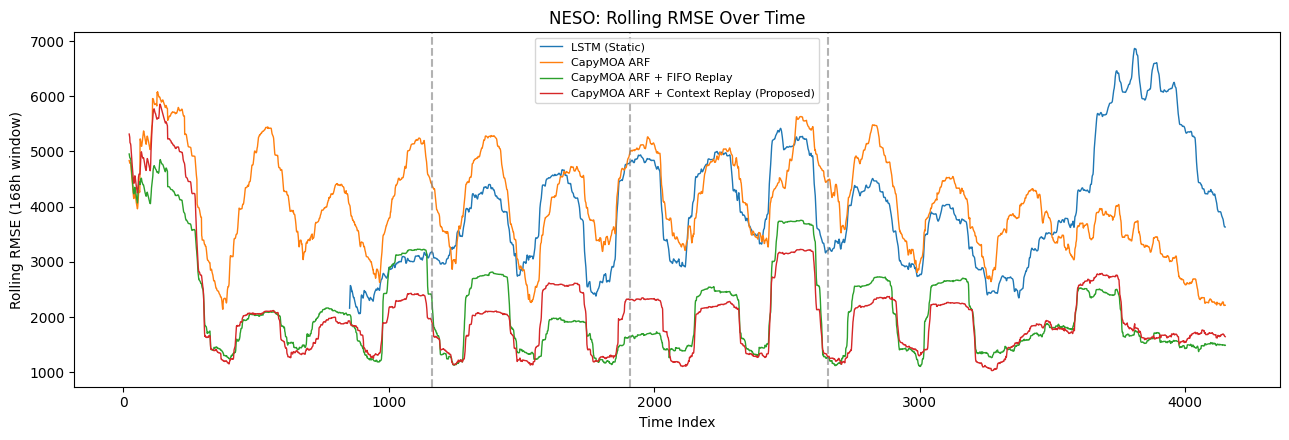

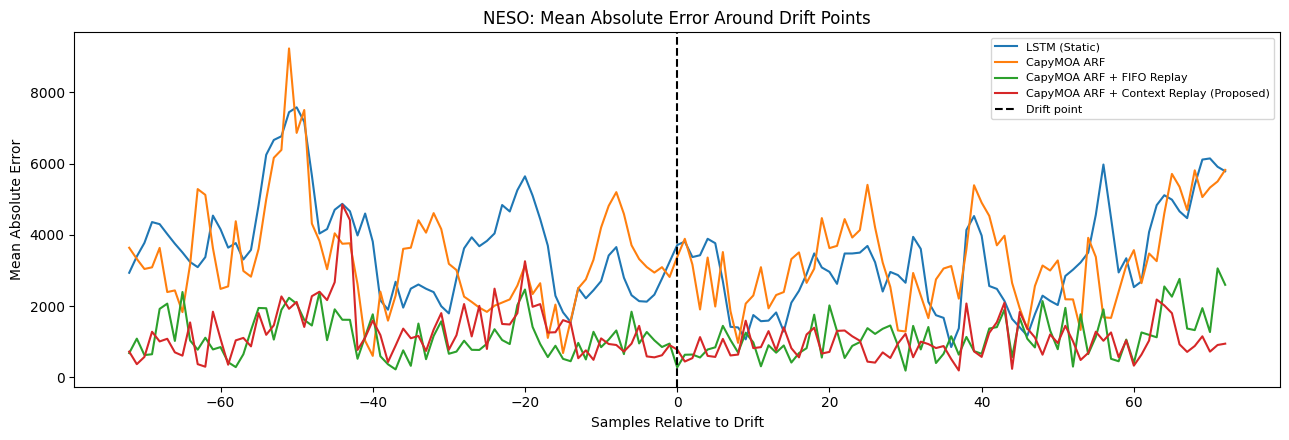

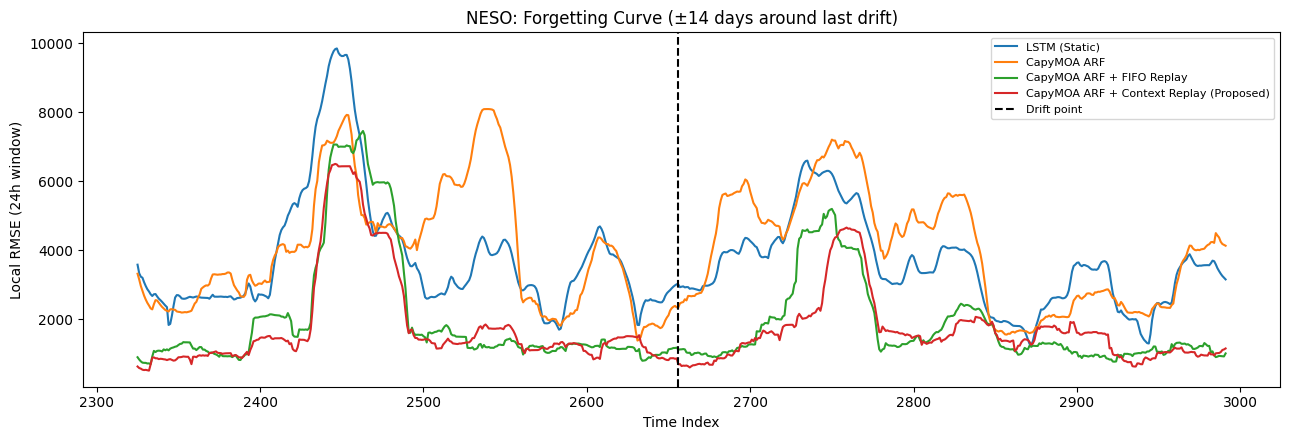

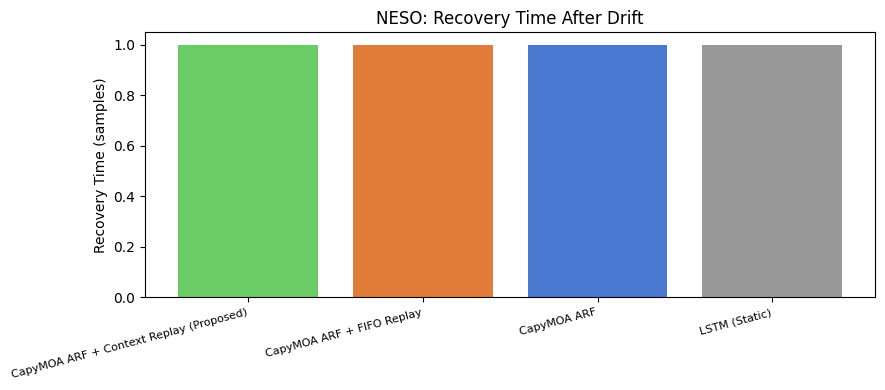

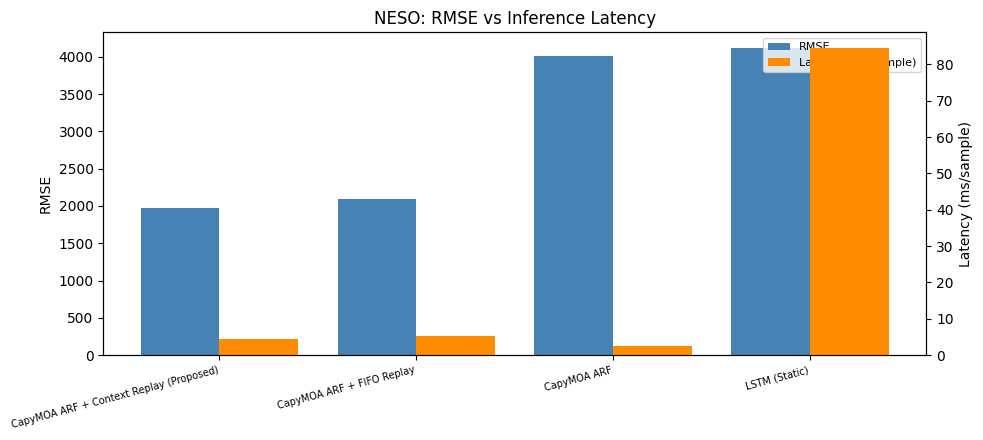

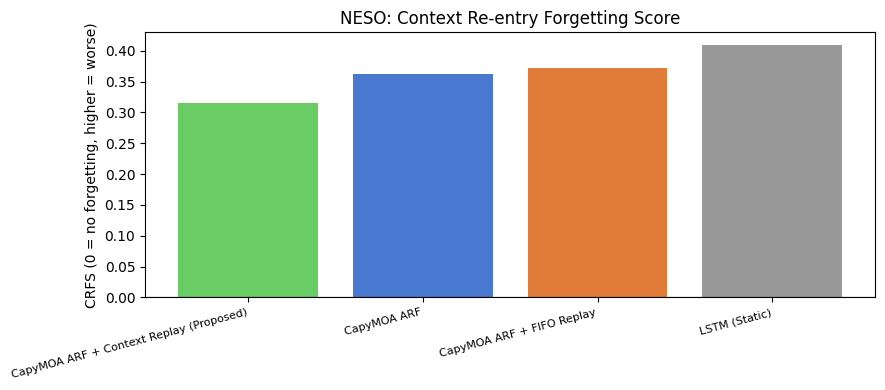

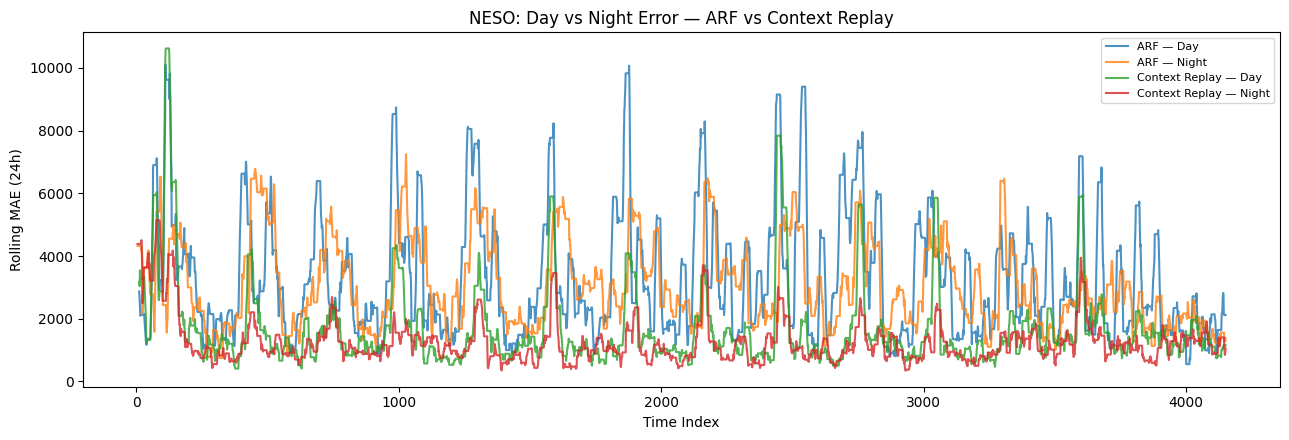

Plots saved → outputs/neso

--- NESO RESULTS ---


,Model,Dataset,RMSE,MAE,R2,Latency_ms_per_sample,Recovery_Time,Forgetting_Score
0,CapyMOA ARF + Context Replay (Proposed),NESO,1976.1683,1357.0653,0.9156,4.4564,1.0000,0.3158
1,CapyMOA ARF + FIFO Replay,NESO,2087.8236,1382.3854,0.9058,5.4020,1.0000,0.3721
2,CapyMOA ARF,NESO,4004.1229,3122.0011,0.6534,2.4436,1.0000,0.3630
3,LSTM (Static),NESO,4121.8938,3208.3550,0.6327,84.5814,1.0000,0.4095


In [12]:
print("=" * 60)
print("EXPERIMENT 1: NESO (United Kingdom)")
print("=" * 60)

neso_raw        = load_neso_data(n_years=NESO_YEARS, max_samples=NESO_MAX_SAMPLES, seed=SEED)
neso_bundle     = preprocess_data(neso_raw, window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)
neso_ref_drifts = detect_reference_drifts(neso_bundle["y_original"],
                                           delta=ADWIN_DELTA,
                                           eval_start=neso_bundle["split_idx"])

print(f"Samples       : {neso_bundle['n_samples']}")
print(f"Train / Eval  : {neso_bundle['split_idx']} / {neso_bundle['n_samples'] - neso_bundle['split_idx']}")
print(f"Features      : {neso_bundle['n_features']} ({neso_bundle['feature_cols']})")
print(f"Ref. drifts   : {neso_ref_drifts}")

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
neso_metrics_df, neso_outputs, neso_plot_dir = run_full_experiment(
    "NESO", neso_bundle, neso_ref_drifts, LSTM_EPOCHS_PRIMARY, seed=SEED)

print("\n--- NESO RESULTS ---")
display(neso_metrics_df)

## Cell 12 — Robustness Experiment: UCI Electricity (Portugal)

Repeats the same experiment on the UCI dataset to confirm results generalise beyond NESO. Set `RUN_ROBUSTNESS = False` in Cell 3 to skip.

**Expected runtime:** ~10–15 minutes.

EXPERIMENT 2: UCI Electricity (Portugal)
Samples       : 7832
Train / Eval  : 1566 / 6266
Ref. drifts   : [2192, 3602, 5012]

[1/4] Training LSTM (UCI Electricity)...
      Done.

[2/4] Running ARF (UCI Electricity)...
      Done.
[3/4] Running ARF + FIFO Replay (UCI Electricity)...
      Done.
[4/4] Running ARF + Context Replay (UCI Electricity, Proposed)...
      Done.


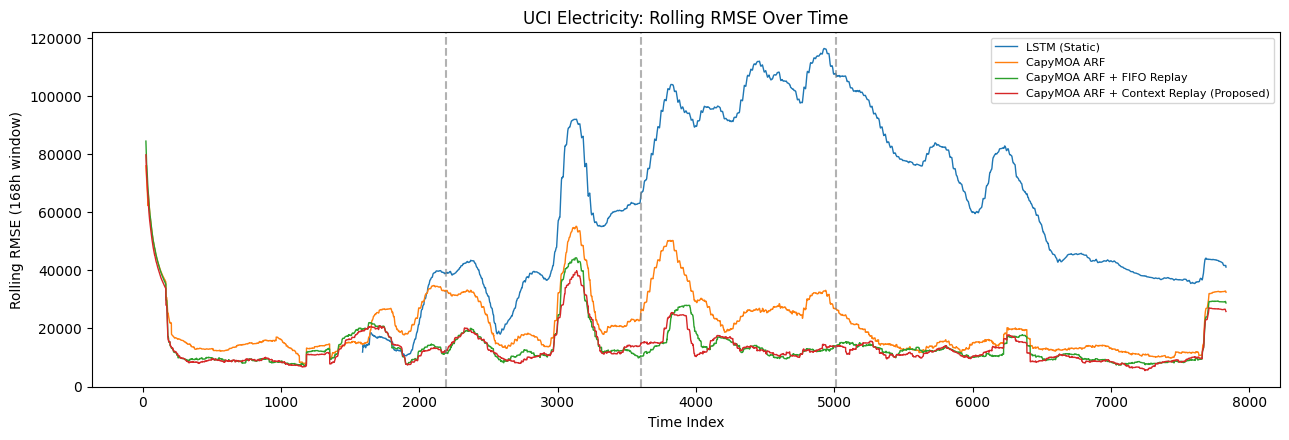

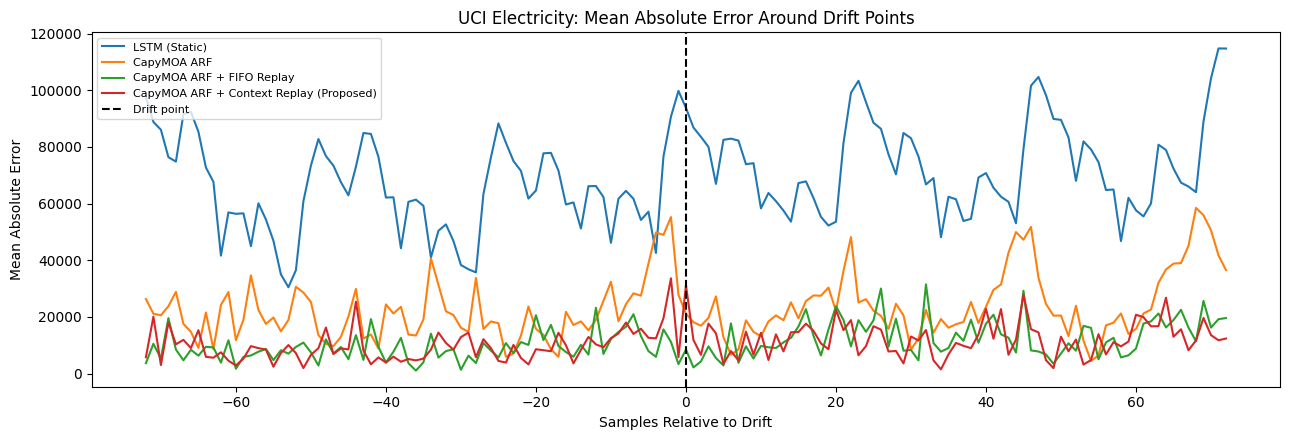

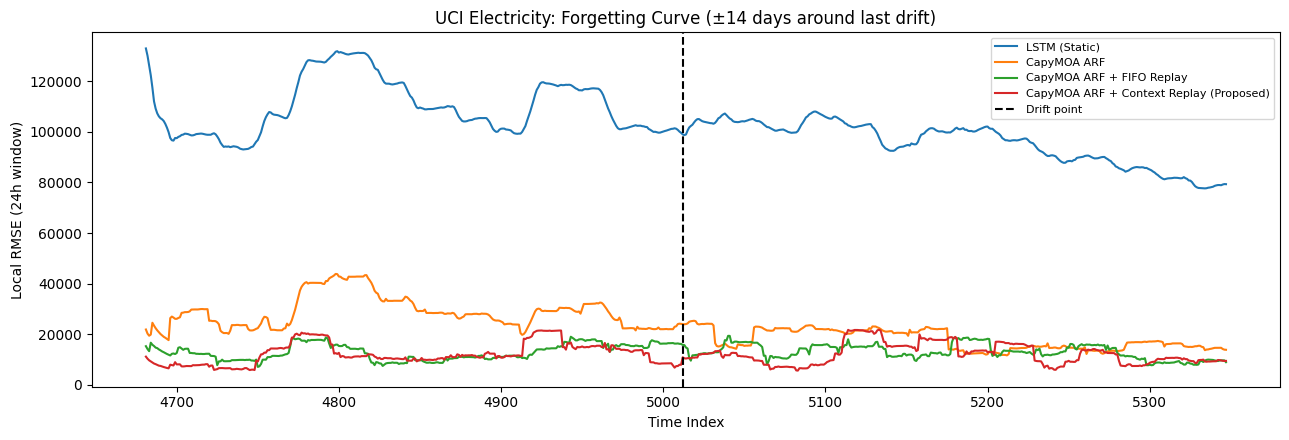

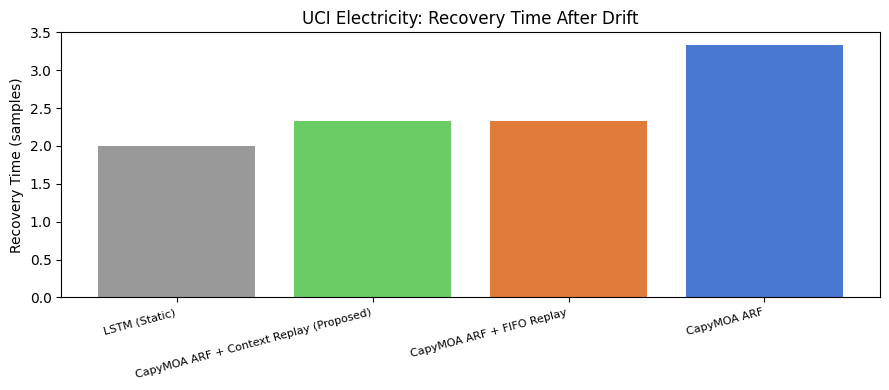

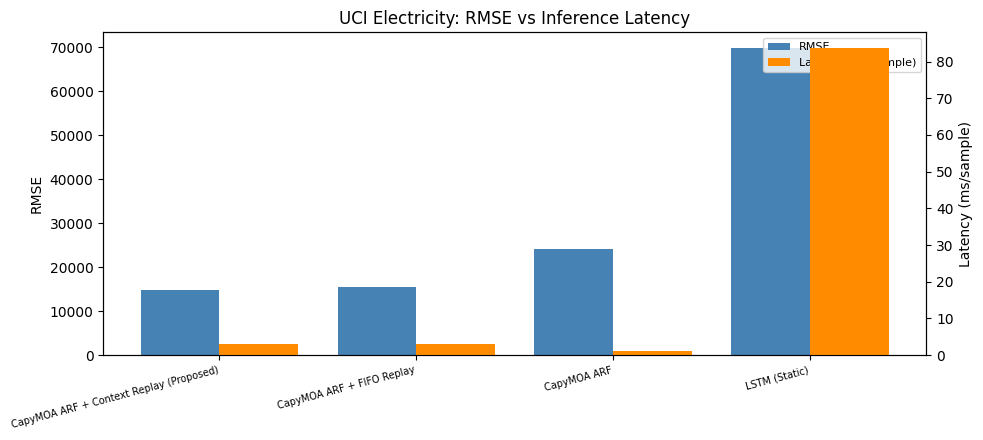

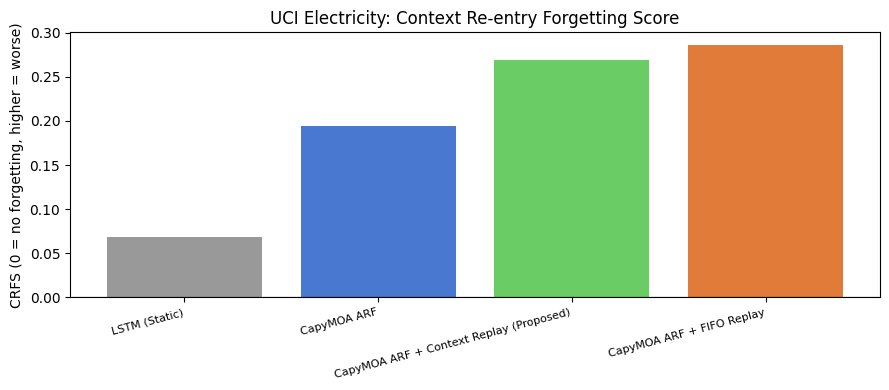

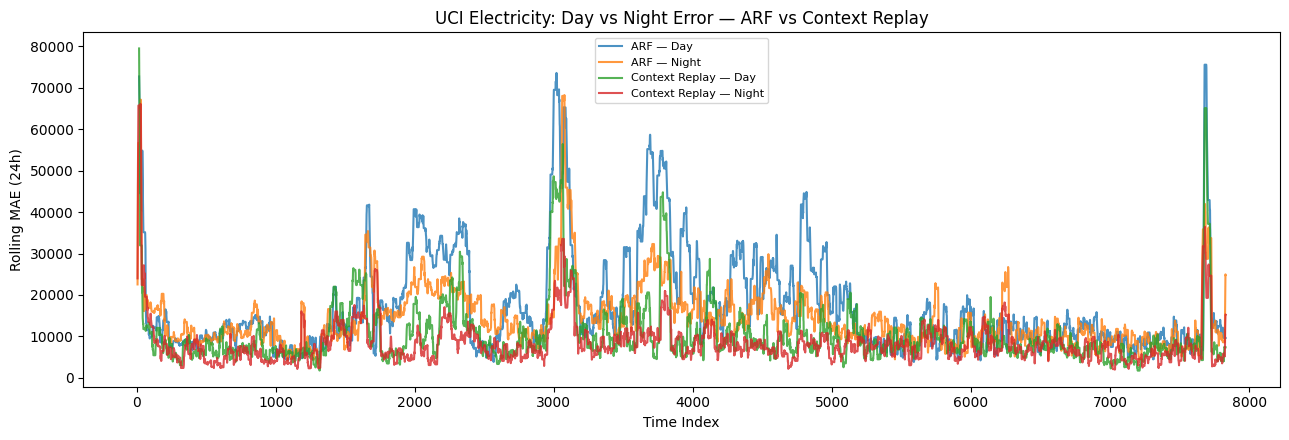

Plots saved → outputs/uci_electricity

--- UCI RESULTS ---


,Model,Dataset,RMSE,MAE,R2,Latency_ms_per_sample,Recovery_Time,Forgetting_Score
0,CapyMOA ARF + Context Replay (Proposed),UCI Electricity,14824.8123,9599.2890,0.9698,3.0588,2.3333,0.2691
1,CapyMOA ARF + FIFO Replay,UCI Electricity,15588.4383,9858.8564,0.9666,3.1132,2.3333,0.2860
2,CapyMOA ARF,UCI Electricity,24227.4966,16903.9449,0.9194,1.0123,3.3333,0.1940
3,LSTM (Static),UCI Electricity,69924.1456,58507.1982,0.3283,83.7711,2.0000,0.0686


In [13]:
all_metrics   = [neso_metrics_df.copy()]
all_plot_dirs = [neso_plot_dir]

if RUN_ROBUSTNESS:
    print("=" * 60)
    print("EXPERIMENT 2: UCI Electricity (Portugal)")
    print("=" * 60)

    uci_raw        = load_uci_electricity_data(max_samples=UCI_MAX_SAMPLES)
    uci_bundle     = preprocess_data(uci_raw, window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)
    uci_ref_drifts = detect_reference_drifts(uci_bundle["y_original"],
                                              delta=ADWIN_DELTA,
                                              eval_start=uci_bundle["split_idx"])

    print(f"Samples       : {uci_bundle['n_samples']}")
    print(f"Train / Eval  : {uci_bundle['split_idx']} / {uci_bundle['n_samples'] - uci_bundle['split_idx']}")
    print(f"Ref. drifts   : {uci_ref_drifts}")

    uci_metrics_df, uci_outputs, uci_plot_dir = run_full_experiment(
        "UCI Electricity", uci_bundle, uci_ref_drifts, LSTM_EPOCHS_ROBUST, seed=SEED)

    print("\n--- UCI RESULTS ---")
    display(uci_metrics_df)

    all_metrics.append(uci_metrics_df.copy())
    all_plot_dirs.append(uci_plot_dir)
else:
    print("Skipped UCI (RUN_ROBUSTNESS=False).")

## Cell 13 — Generalisability Experiment: AEMO NSW (Australia)

Third dataset from the Southern Hemisphere. Australia's inverted seasonal cycle (summer in Dec–Feb) provides a genuine stress test — the seasonal drift patterns are temporally opposite to UK and Portugal. Set `RUN_AEMO = False` in Cell 3 to skip.

**Note:** If the AEMO download fails, the code falls back to synthetic NSW-like demand data for pipeline validation. Replace with actual AEMO CSV files for final publication results.

**Expected runtime:** ~12–18 minutes.

EXPERIMENT 3: AEMO NSW (Australia)
  Downloaded: 202512 (8928 rows)
  Downloaded: 202511 (8640 rows)
  Downloaded: 202510 (8928 rows)
  Downloaded: 202509 (8640 rows)
  Downloaded: 202508 (8928 rows)
  Downloaded: 202507 (8928 rows)
  Downloaded: 202506 (8640 rows)
  Downloaded: 202505 (8928 rows)
  Downloaded: 202504 (8640 rows)
  Downloaded: 202503 (8928 rows)
  Downloaded: 202502 (8064 rows)
  Downloaded: 202501 (8928 rows)
  Downloaded: 202412 (8928 rows)
  Downloaded: 202411 (8640 rows)
  Downloaded: 202410 (8928 rows)
  Downloaded: 202409 (8640 rows)
  Downloaded: 202408 (8928 rows)
  Downloaded: 202407 (8928 rows)
  Downloaded: 202406 (8640 rows)
  Downloaded: 202405 (8928 rows)
  Downloaded: 202404 (8640 rows)
  Downloaded: 202403 (8928 rows)
  Downloaded: 202402 (8352 rows)
  Downloaded: 202401 (8928 rows)
  Total rows downloaded: 210528
  Columns: ['REGION', 'SETTLEMENTDATE', 'TOTALDEMAND', 'RRP', 'PERIODTYPE']
  Hourly samples after resampling: 17545
Samples       : 17377
Tr

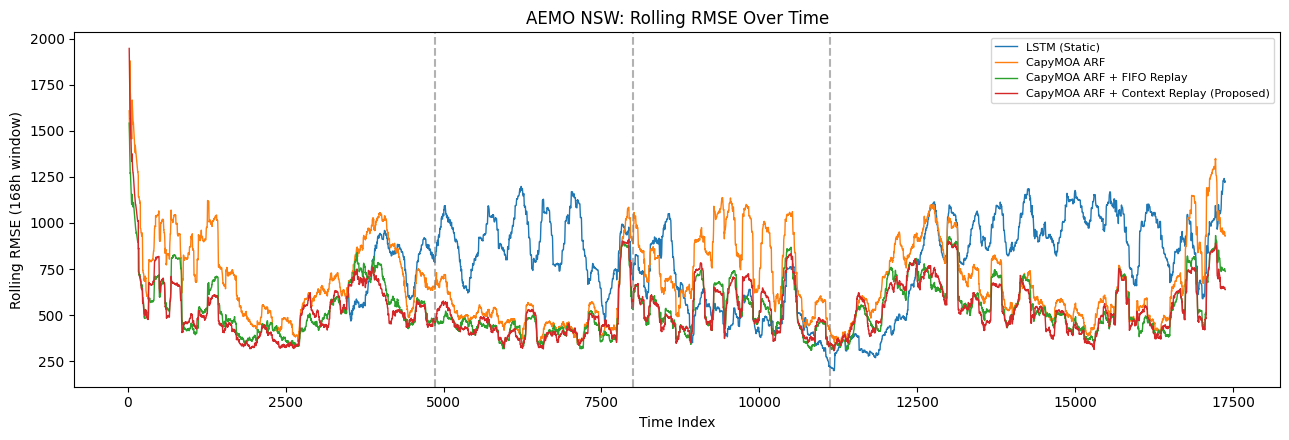

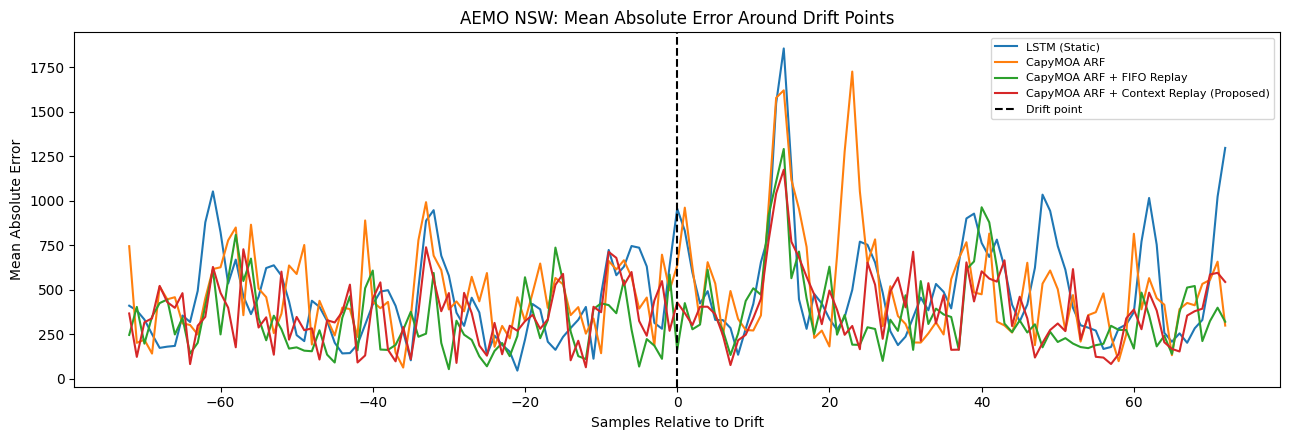

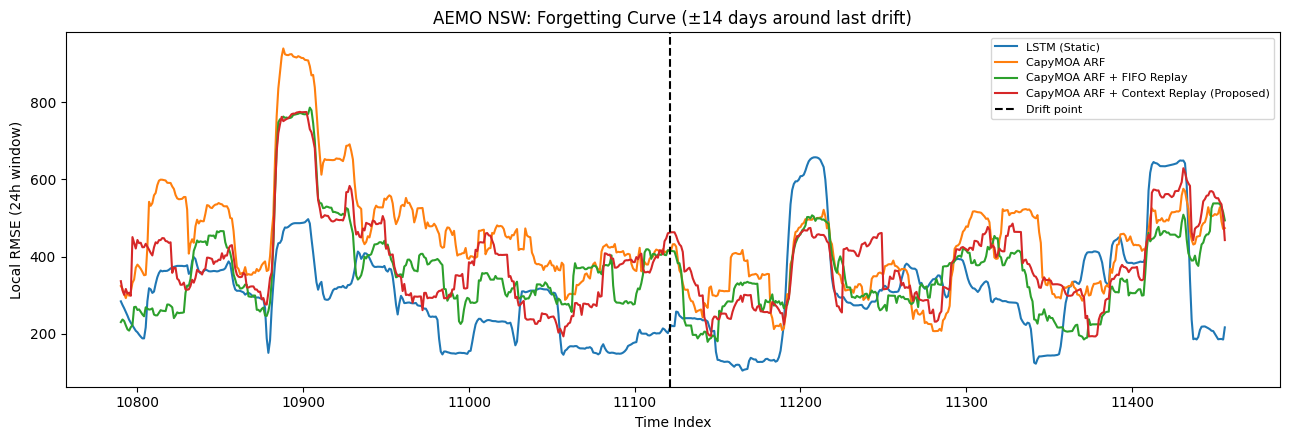

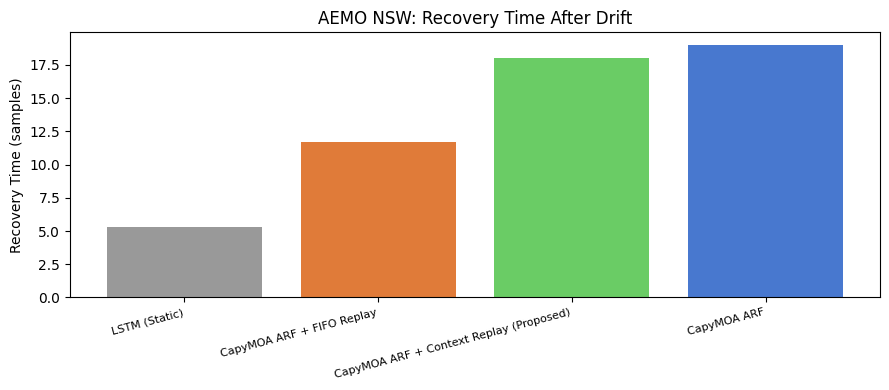

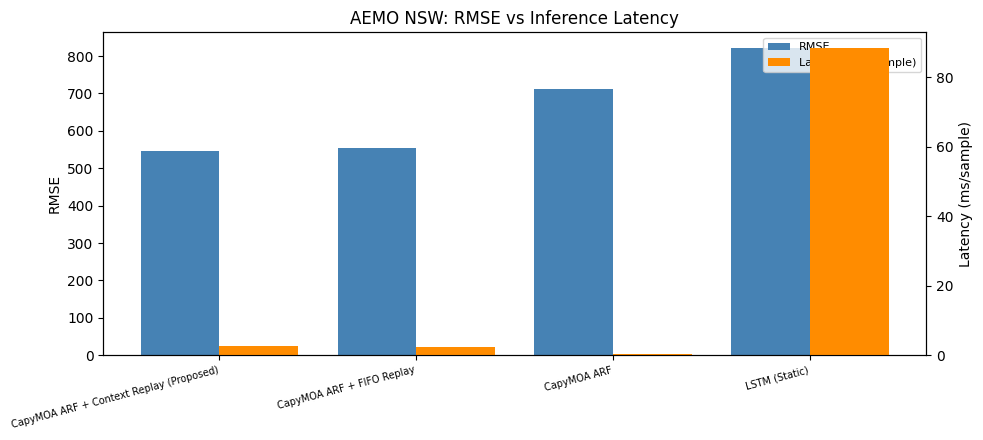

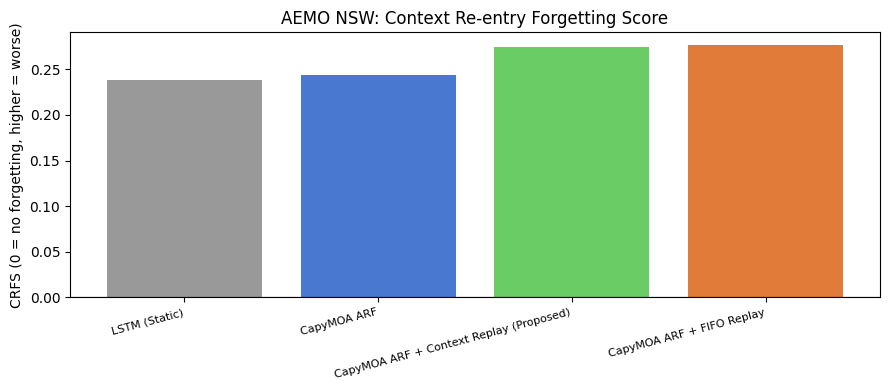

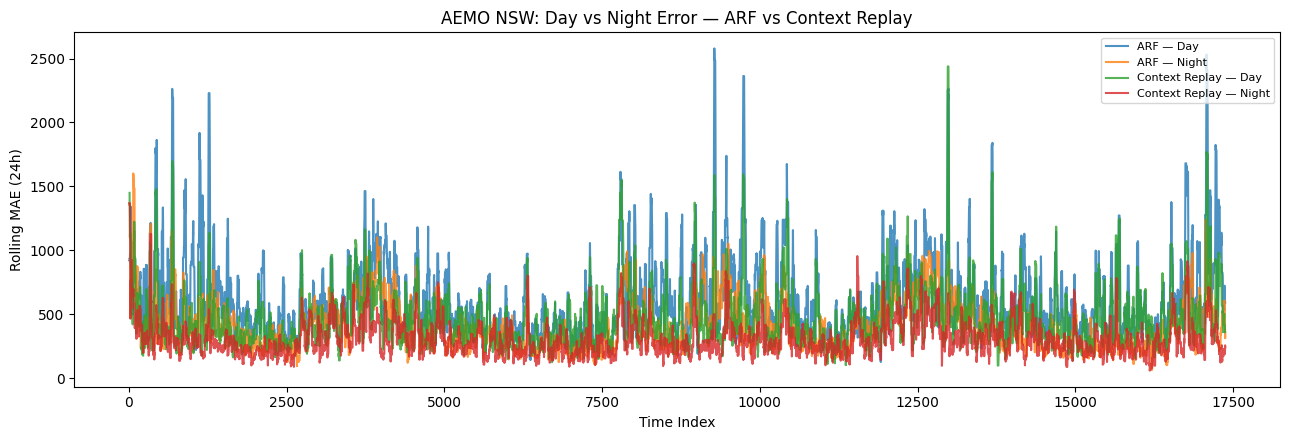

Plots saved → outputs/aemo_nsw

--- AEMO RESULTS ---


,Model,Dataset,RMSE,MAE,R2,Latency_ms_per_sample,Recovery_Time,Forgetting_Score
0,CapyMOA ARF + Context Replay (Proposed),AEMO NSW,546.4667,392.0269,0.8791,2.6484,18.0000,0.2744
1,CapyMOA ARF + FIFO Replay,AEMO NSW,553.3975,392.2467,0.8760,2.3840,11.6667,0.2766
2,CapyMOA ARF,AEMO NSW,711.5096,515.3459,0.7950,0.3740,19.0000,0.2435
3,LSTM (Static),AEMO NSW,822.1887,601.6931,0.7262,88.4630,5.3333,0.2387


In [14]:
# ── Run AEMO experiment ──────────────────────────────────────
if RUN_AEMO:
    print("=" * 60)
    print("EXPERIMENT 3: AEMO NSW (Australia)")
    print("=" * 60)

    aemo_raw        = load_aemo_data(max_samples=AEMO_MAX_SAMPLES)
    aemo_bundle     = preprocess_data(aemo_raw, window_size=WINDOW_SIZE, train_ratio=TRAIN_RATIO)
    aemo_ref_drifts = detect_reference_drifts(aemo_bundle["y_original"],
                                               delta=ADWIN_DELTA,
                                               eval_start=aemo_bundle["split_idx"])

    print(f"Samples       : {aemo_bundle['n_samples']}")
    print(f"Train / Eval  : {aemo_bundle['split_idx']} / {aemo_bundle['n_samples'] - aemo_bundle['split_idx']}")
    print(f"Ref. drifts   : {aemo_ref_drifts}")

    aemo_metrics_df, aemo_outputs, aemo_plot_dir = run_full_experiment(
        "AEMO NSW", aemo_bundle, aemo_ref_drifts, LSTM_EPOCHS_ROBUST, seed=SEED)

    print("\n--- AEMO RESULTS ---")
    display(aemo_metrics_df)

    all_metrics.append(aemo_metrics_df.copy())
    all_plot_dirs.append(aemo_plot_dir)
else:
    print("Skipped AEMO (RUN_AEMO=False).")

## Cell 14 — Combined Results Table

Merges all dataset results into one table. Saved to `outputs/final_results_table.csv`.

In [15]:
final_results = pd.concat(all_metrics, ignore_index=True)
final_results = final_results[
    ["Model","Dataset","RMSE","MAE","R2","Latency_ms_per_sample","Recovery_Time","Forgetting_Score"]
].sort_values(["Dataset","RMSE"]).reset_index(drop=True)

print("=" * 60)
print("FINAL COMBINED RESULTS — ALL DATASETS")
print("=" * 60)
display(final_results)

final_results.to_csv(os.path.join(OUTPUT_DIR, "final_results_table.csv"), index=False)
print("\nSaved: outputs/final_results_table.csv")
print()
print("CRFS key: 0 = no forgetting  |  higher = more forgetting")
print("Expected: Context Replay has lowest CRFS among replay methods on all datasets")

FINAL COMBINED RESULTS — ALL DATASETS


,Model,Dataset,RMSE,MAE,R2,Latency_ms_per_sample,Recovery_Time,Forgetting_Score
0,CapyMOA ARF + Context Replay (Proposed),AEMO NSW,546.4667,392.0269,0.8791,2.6484,18.0000,0.2744
1,CapyMOA ARF + FIFO Replay,AEMO NSW,553.3975,392.2467,0.8760,2.3840,11.6667,0.2766
2,CapyMOA ARF,AEMO NSW,711.5096,515.3459,0.7950,0.3740,19.0000,0.2435
3,LSTM (Static),AEMO NSW,822.1887,601.6931,0.7262,88.4630,5.3333,0.2387
4,CapyMOA ARF + Context Replay (Proposed),NESO,1976.1683,1357.0653,0.9156,4.4564,1.0000,0.3158
5,CapyMOA ARF + FIFO Replay,NESO,2087.8236,1382.3854,0.9058,5.4020,1.0000,0.3721
6,CapyMOA ARF,NESO,4004.1229,3122.0011,0.6534,2.4436,1.0000,0.3630
7,LSTM (Static),NESO,4121.8938,3208.3550,0.6327,84.5814,1.0000,0.4095
8,CapyMOA ARF + Context Replay (Proposed),UCI Electricity,14824.8123,9599.2890,0.9698,3.0588,2.3333,0.2691
9,CapyMOA ARF + FIFO Replay,UCI Electricity,15588.4383,9858.8564,0.9666,3.1132,2.3333,0.2860



Saved: outputs/final_results_table.csv

CRFS key: 0 = no forgetting  |  higher = more forgetting
Expected: Context Replay has lowest CRFS among replay methods on all datasets


## Cell 15 — Multi-Seed Validation (10 Seeds)

Re-runs the three ARF-based models with **10 different random seeds** on the NESO dataset. This provides sufficient statistical power for Wilcoxon signed-rank tests (n=10 can reach p ≈ 0.002 if all differences are consistent).

The `seed` parameter is passed to **both** the ARF learner (`random_seed`) **and** the replay RNG, ensuring complete variation across runs.

LSTM is excluded — it is a static model unaffected by seed after training.

**Expected runtime:** ~50–70 minutes (10 seeds × 3 models).

In [16]:
print("=" * 60)
print(f"MULTI-SEED VALIDATION ({len(MULTI_SEEDS)} seeds × 3 models)")
print("=" * 60)

seed_records = []

for s in MULTI_SEEDS:
    print(f"\n--- Seed {s} ---")
    np.random.seed(s); random.seed(s)

    out_arf    = run_capymoa_arf(neso_bundle, ARF_TREES, ADWIN_DELTA, seed=s)
    row_arf, _ = evaluate_model("NESO", neso_bundle, out_arf, neso_ref_drifts)
    seed_records.append({"seed": s, "model": "CapyMOA ARF",
                         **{k: row_arf[k] for k in ["RMSE","MAE","R2","Recovery_Time","Forgetting_Score"]}})
    print(f"  ARF       RMSE={row_arf['RMSE']:.1f}  CRFS={row_arf['Forgetting_Score']:.4f}")

    out_fifo    = run_capymoa_arf_with_fifo_replay(
        neso_bundle, ARF_TREES, ADWIN_DELTA,
        replay_k=REPLAY_K_SAME + REPLAY_K_CROSS,
        buffer_size=REPLAY_BUFFER_SIZE * 2, seed=s)
    row_fifo, _ = evaluate_model("NESO", neso_bundle, out_fifo, neso_ref_drifts)
    seed_records.append({"seed": s, "model": "CapyMOA ARF + FIFO Replay",
                         **{k: row_fifo[k] for k in ["RMSE","MAE","R2","Recovery_Time","Forgetting_Score"]}})
    print(f"  FIFO      RMSE={row_fifo['RMSE']:.1f}  CRFS={row_fifo['Forgetting_Score']:.4f}")

    out_ctx    = run_capymoa_arf_with_replay(
        neso_bundle, ARF_TREES, ADWIN_DELTA,
        replay_k_same=REPLAY_K_SAME, replay_k_cross=REPLAY_K_CROSS,
        buffer_size=REPLAY_BUFFER_SIZE, seed=s)
    row_ctx, _ = evaluate_model("NESO", neso_bundle, out_ctx, neso_ref_drifts)
    seed_records.append({"seed": s, "model": "CapyMOA ARF + Context Replay (Proposed)",
                         **{k: row_ctx[k] for k in ["RMSE","MAE","R2","Recovery_Time","Forgetting_Score"]}})
    print(f"  Context   RMSE={row_ctx['RMSE']:.1f}  CRFS={row_ctx['Forgetting_Score']:.4f}")

seed_df = pd.DataFrame(seed_records)

print(f"\n--- MULTI-SEED SUMMARY (mean ± std, n={len(MULTI_SEEDS)}) ---")
summary_stats = seed_df.groupby("model")[["RMSE","MAE","R2","Forgetting_Score"]].agg(["mean","std"])
display(summary_stats)

seed_df.to_csv(os.path.join(OUTPUT_DIR, "multi_seed_results.csv"), index=False)
print("Saved: outputs/multi_seed_results.csv")

MULTI-SEED VALIDATION (10 seeds × 3 models)

--- Seed 42 ---
  ARF       RMSE=4004.1  CRFS=0.3630
  FIFO      RMSE=2087.8  CRFS=0.3721
  Context   RMSE=1976.2  CRFS=0.3158

--- Seed 123 ---
  ARF       RMSE=3936.4  CRFS=0.3463
  FIFO      RMSE=1990.9  CRFS=0.3520
  Context   RMSE=1971.7  CRFS=0.3431

--- Seed 456 ---
  ARF       RMSE=3912.3  CRFS=0.3741
  FIFO      RMSE=2035.6  CRFS=0.3983
  Context   RMSE=2047.3  CRFS=0.3520

--- Seed 789 ---
  ARF       RMSE=3919.6  CRFS=0.3418
  FIFO      RMSE=1917.7  CRFS=0.2992
  Context   RMSE=1895.9  CRFS=0.3202

--- Seed 1011 ---
  ARF       RMSE=3950.5  CRFS=0.3701
  FIFO      RMSE=2056.4  CRFS=0.3678
  Context   RMSE=1949.5  CRFS=0.3339

--- Seed 2022 ---
  ARF       RMSE=3957.5  CRFS=0.3675
  FIFO      RMSE=2195.1  CRFS=0.3939
  Context   RMSE=2118.3  CRFS=0.3864

--- Seed 3033 ---
  ARF       RMSE=4045.0  CRFS=0.3773
  FIFO      RMSE=1943.6  CRFS=0.3303
  Context   RMSE=2055.1  CRFS=0.3203

--- Seed 4044 ---
  ARF       RMSE=4087.4  CRFS=0.

RMSE               MAE          \
                                             mean     std      mean     std   
model                                                                         
CapyMOA ARF                             3961.4086 64.5249 3085.3089 45.3085   
CapyMOA ARF + Context Replay (Proposed) 2021.3919 77.0383 1378.7593 34.9598   
CapyMOA ARF + FIFO Replay               2025.0356 78.7124 1374.8850 25.1037   

                                            R2        Forgetting_Score         
                                          mean    std             mean    std  
model                                                                          
CapyMOA ARF                             0.6607 0.0111           0.3622 0.0118  
CapyMOA ARF + Context Replay (Proposed) 0.9116 0.0067           0.3406 0.0251  
CapyMOA ARF + FIFO Replay               0.9112 0.0070           0.3563 0.0307

Saved: outputs/multi_seed_results.csv


## Cell 16 — Statistical Significance (Wilcoxon Signed-Rank Tests)

Tests whether improvements are statistically significant across seeds. With n=10 paired observations, the test can detect consistent directional effects at p < 0.05.

In [17]:
print("=" * 60)
print("WILCOXON SIGNED-RANK TESTS")
print("=" * 60)

rmse_arf  = seed_df[seed_df["model"]=="CapyMOA ARF"]["RMSE"].values
rmse_fifo = seed_df[seed_df["model"]=="CapyMOA ARF + FIFO Replay"]["RMSE"].values
rmse_ctx  = seed_df[seed_df["model"]=="CapyMOA ARF + Context Replay (Proposed)"]["RMSE"].values
fs_fifo   = seed_df[seed_df["model"]=="CapyMOA ARF + FIFO Replay"]["Forgetting_Score"].values
fs_ctx    = seed_df[seed_df["model"]=="CapyMOA ARF + Context Replay (Proposed)"]["Forgetting_Score"].values

def run_wilcoxon(a, b, label):
    print(f"\n{label}")
    print(f"  Mean A: {np.mean(a):.4f} ± {np.std(a):.4f}")
    print(f"  Mean B: {np.mean(b):.4f} ± {np.std(b):.4f}")
    diff = a - b
    n_positive = np.sum(diff > 0)
    n_negative = np.sum(diff < 0)
    print(f"  Direction: {n_positive} favour A, {n_negative} favour B, {np.sum(diff==0)} tied")
    if len(set(diff)) > 1:
        stat, p = wilcoxon(a, b)
        sig = "SIGNIFICANT ✓" if p < 0.05 else "Not significant"
        print(f"  W={stat:.4f}  p={p:.4f}  → {sig}")
    else:
        print("  Cannot run: all differences are zero.")

run_wilcoxon(rmse_arf,  rmse_ctx,  "H1: ARF vs Context Replay on RMSE")
run_wilcoxon(rmse_fifo, rmse_ctx,  "H2: FIFO vs Context Replay on RMSE")
run_wilcoxon(fs_fifo,   fs_ctx,    "H3: FIFO vs Context Replay on CRFS (primary claim)")

WILCOXON SIGNED-RANK TESTS

H1: ARF vs Context Replay on RMSE
  Mean A: 3961.4086 ± 61.2137
  Mean B: 2021.3919 ± 73.0849
  Direction: 10 favour A, 0 favour B, 0 tied
  W=0.0000  p=0.0020  → SIGNIFICANT ✓

H2: FIFO vs Context Replay on RMSE
  Mean A: 2025.0356 ± 74.6731
  Mean B: 2021.3919 ± 73.0849
  Direction: 6 favour A, 4 favour B, 0 tied
  W=24.0000  p=0.7695  → Not significant

H3: FIFO vs Context Replay on CRFS (primary claim)
  Mean A: 0.3563 ± 0.0291
  Mean B: 0.3406 ± 0.0238
  Direction: 8 favour A, 2 favour B, 0 tied
  W=12.0000  p=0.1309  → Not significant


## Cell 17 — Multi-Seed Box Plot

Visual comparison of RMSE, MAE, R², and CRFS distributions across 10 seeds. Tight boxes indicate stable results. Context Replay should show lower median CRFS than FIFO.

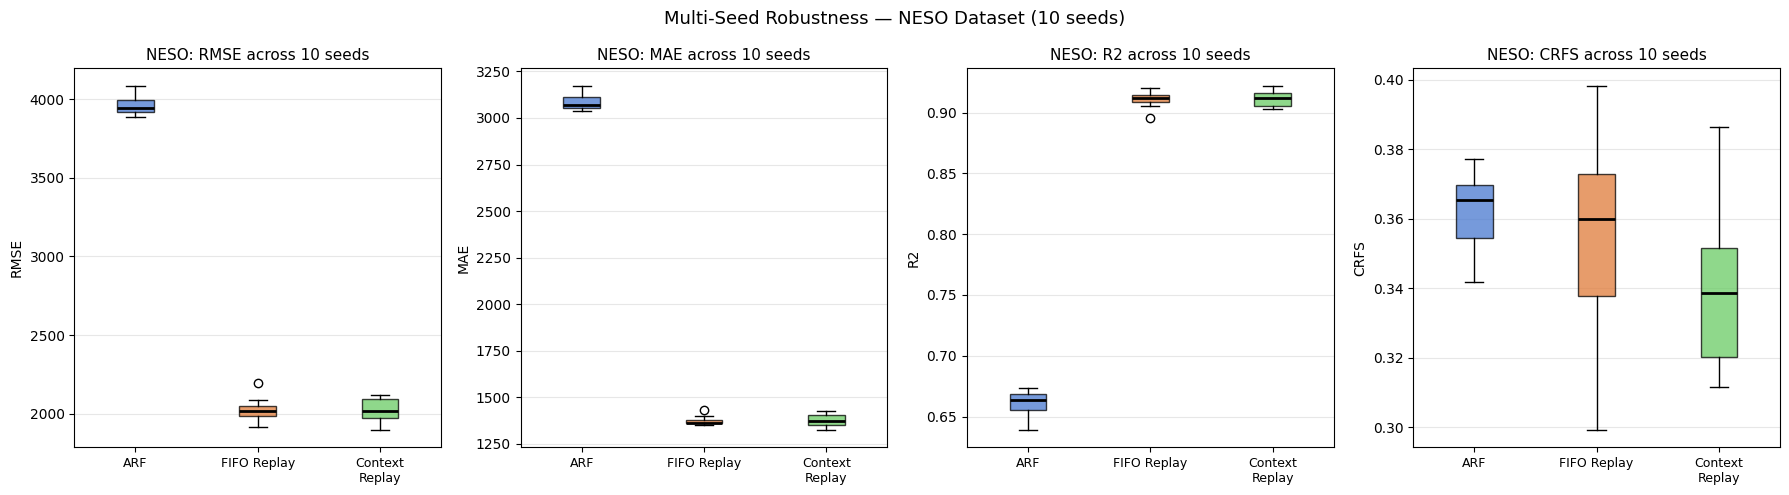

Saved: outputs/multi_seed_boxplot.png


In [18]:
model_order = ["CapyMOA ARF",
               "CapyMOA ARF + FIFO Replay",
               "CapyMOA ARF + Context Replay (Proposed)"]
short_names = ["ARF", "FIFO Replay", "Context\nReplay"]
colors      = ["#4878cf", "#e07b39", "#6acc65"]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, metric in zip(axes, ["RMSE", "MAE", "R2", "Forgetting_Score"]):
    data = [seed_df[seed_df["model"]==m][metric].values for m in model_order]
    bp   = ax.boxplot(data, patch_artist=True,
                      medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    ax.set_xticks([1,2,3]); ax.set_xticklabels(short_names, fontsize=9)
    label = "CRFS" if metric == "Forgetting_Score" else metric
    ax.set_title(f"NESO: {label} across {len(MULTI_SEEDS)} seeds", fontsize=11)
    ax.set_ylabel(label); ax.grid(axis="y", alpha=0.3)

plt.suptitle(f"Multi-Seed Robustness — NESO Dataset ({len(MULTI_SEEDS)} seeds)", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "multi_seed_boxplot.png"), dpi=300)
plt.show()
print("Saved: outputs/multi_seed_boxplot.png")

## Cell 18 — Ablation Study

Three ablated variants isolate the contribution of each component:

| Variant | What's Disabled | Tests |
|---|---|---|
| **A1** — No Level 1 | `k_same = k_cross = 0` (no per-step replay) | Is continuous balanced replay the dominant component? |
| **A2** — No Level 2 | `k_warmup = 0` (no drift-gated warm-up) | Does the warm-up burst help specifically at re-entry? |
| **A3** — No Context Split | Single unified buffer, `k_total = 10` | Is partitioning independently valuable beyond just replaying? |

All variants use the **same total computational budget** as the full method.


ABLATION STUDY — Context Replay (NESO)

▶ A1 — No Level 1 (Drift-Gated Only) ...
  RMSE=3269.0  CRFS=0.3812

▶ A2 — No Level 2 (Per-Step Only) ...
  RMSE=2127.6  CRFS=0.3359

▶ A3 — No Context Split (Unified k=10) ...
  RMSE=2013.5  CRFS=0.3714

ABLATION TABLE


,Model,RMSE,MAE,R2,Forgetting_Score,delta_RMSE,delta_Forgetting_Score
0,Full Context Replay (Proposed),1976.1683,1357.0653,0.9156,0.3158,—,—
1,A1 — No Level 1 (Drift-Gated Only),3269.0360,2390.9596,0.7690,0.3812,+1292.9,+0.1
2,A2 — No Level 2 (Per-Step Only),2127.5621,1432.6231,0.9022,0.3359,+151.4,+0.0
3,A3 — No Context Split (Unified k=10),2013.5189,1378.2622,0.9124,0.3714,+37.4,+0.1


Saved → outputs/ablation_results.csv


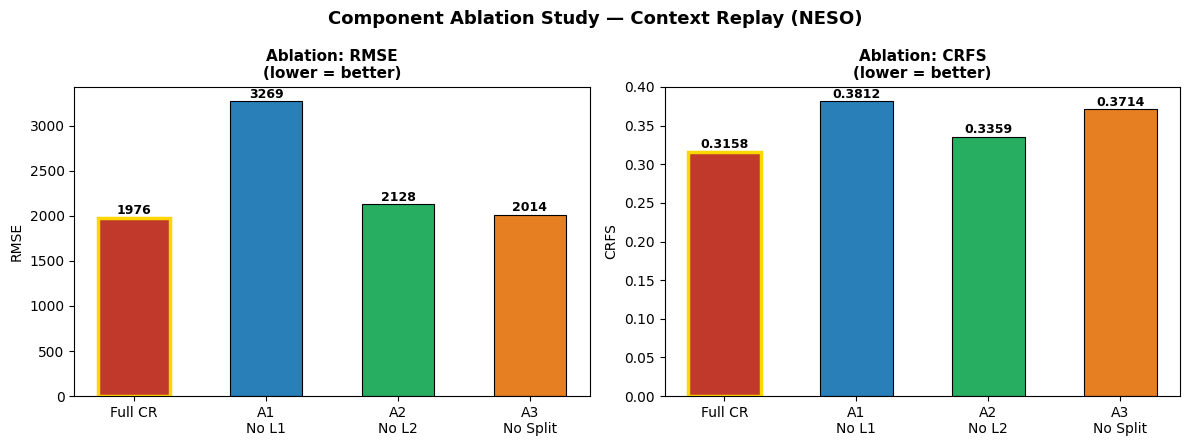

Saved → outputs/ablation_study.png


In [19]:
def run_ablation(bundle, model_name, k_same, k_cross, k_warmup,
                 unified=False, n_trees=None, delta=None, seed=None):
    if n_trees is None: n_trees = ARF_TREES
    if delta   is None: delta   = ADWIN_DELTA
    if seed    is None: seed    = SEED

    X            = bundle["X_scaled"].astype(np.float64)
    y            = bundle["y_original"].astype(np.float64)
    is_day       = bundle["is_day_array"].astype(int)
    feature_cols = bundle["feature_cols"]
    target_col   = bundle["target_col"]
    buf_size     = REPLAY_BUFFER_SIZE

    stream  = NumpyStream(X=X, y=y, dataset_name="abl_stream",
                          feature_names=feature_cols, target_name=target_col, target_type="numeric")
    learner = AdaptiveRandomForestRegressor(
        schema=stream.get_schema(), ensemble_size=n_trees, random_seed=seed)
    detector   = create_capymoa_adwin(delta=delta)
    rng        = np.random.default_rng(seed)

    day_buf    = deque(maxlen=buf_size)
    night_buf  = deque(maxlen=buf_size)
    uni_buf    = deque(maxlen=buf_size * 2)

    y_pred_full  = np.full(len(y), np.nan, dtype=np.float64)
    drifts       = []
    pred_ns = train_ns = 0
    running_mean = float(y[0])
    prev_ctx     = int(is_day[0])
    last_drift_at = -DRIFT_MEMORY - 1

    def _do_replay(buf_items, k):
        nonlocal train_ns
        if len(buf_items) < 2 or k <= 0: return
        chosen = rng.choice(len(buf_items), size=min(k, len(buf_items)), replace=False)
        X_r = np.vstack([buf_items[int(j)][0] for j in np.atleast_1d(chosen)])
        y_r = np.array([buf_items[int(j)][1] for j in np.atleast_1d(chosen)], dtype=np.float64)
        rs  = NumpyStream(X=X_r, y=y_r, dataset_name="replay",
                          feature_names=feature_cols, target_name=target_col, target_type="numeric")
        while rs.has_more_instances():
            ri = rs.next_instance(); t = time.perf_counter_ns()
            learner.train(ri); train_ns += time.perf_counter_ns() - t

    for i in range(len(y)):
        inst = stream.next_instance()
        t0   = time.perf_counter_ns()
        pred = learner.predict(inst)
        pred_ns += time.perf_counter_ns() - t0
        if pred is None: pred = running_mean
        pred   = float(np.squeeze(pred))
        y_true = float(inst.y_value)
        y_pred_full[i] = pred
        if adwin_update_and_detect(detector, abs(y_true - pred)):
            drifts.append(i); last_drift_at = i
        t1 = time.perf_counter_ns(); learner.train(inst); train_ns += time.perf_counter_ns() - t1

        curr_ctx = int(is_day[i])
        x_copy   = X[i].copy()

        if unified:
            uni_buf.append((x_copy, y_true))
        else:
            (day_buf if curr_ctx == 1 else night_buf).append((x_copy, y_true))

        # Level 1: per-step replay
        if not unified:
            same_buf  = list(day_buf if curr_ctx == 1 else night_buf)
            cross_buf = list(night_buf if curr_ctx == 1 else day_buf)
            _do_replay(same_buf, k_same)
            _do_replay(cross_buf, k_cross)
        else:
            _do_replay(list(uni_buf), k_same + k_cross)

        # Level 2: drift-gated warm-up
        if (not unified) and k_warmup > 0:
            if curr_ctx != prev_ctx and (i - last_drift_at) <= DRIFT_MEMORY:
                same_items = list(day_buf if curr_ctx == 1 else night_buf)[:-1]
                if len(same_items) >= 4:
                    _do_replay(same_items, k_warmup)

        prev_ctx     = curr_ctx
        running_mean = (running_mean * i + y_true) / (i + 1)

    return {"model_name": model_name, "y_pred_full": y_pred_full,
            "pred_ns": pred_ns, "train_ns": train_ns, "drift_points": drifts}


print("=" * 60)
print("ABLATION STUDY — Context Replay (NESO)")
print("=" * 60)

ablation_configs = [
    ("A1 — No Level 1 (Drift-Gated Only)", 0, 0, CTX_SWITCH_REPLAY_K, False),
    ("A2 — No Level 2 (Per-Step Only)",    REPLAY_K_SAME, REPLAY_K_CROSS, 0, False),
    ("A3 — No Context Split (Unified k=10)", REPLAY_K_SAME, REPLAY_K_CROSS, 0, True),
]

abl_rows = []
for name, ks, kc, kw, uni in ablation_configs:
    print(f"\n▶ {name} ...")
    out = run_ablation(neso_bundle, name, ks, kc, kw, unified=uni)
    row, _ = evaluate_model("NESO", neso_bundle, out, neso_ref_drifts)
    row["Model"] = name
    abl_rows.append(row)
    print(f"  RMSE={row['RMSE']:.1f}  CRFS={row['Forgetting_Score']:.4f}")

cr_row = neso_metrics_df[
    neso_metrics_df["Model"].str.contains("Context Replay", case=False)
].iloc[0].to_dict()
cr_row["Model"] = "Full Context Replay (Proposed)"

abl_df = pd.DataFrame([cr_row] + abl_rows)

for col in ["RMSE", "Forgetting_Score"]:
    base = float(abl_df.iloc[0][col])
    abl_df[f"delta_{col}"] = abl_df[col].apply(
        lambda v: f"+{float(v)-base:.1f}" if float(v) > base else f"{float(v)-base:.1f}")
    abl_df.at[0, f"delta_{col}"] = "—"

print("\n" + "=" * 60)
print("ABLATION TABLE")
print("=" * 60)
display_cols = ["Model", "RMSE", "MAE", "R2", "Forgetting_Score", "delta_RMSE", "delta_Forgetting_Score"]
display_cols = [c for c in display_cols if c in abl_df.columns]
display(abl_df[display_cols])

abl_df.to_csv(f"{OUTPUT_DIR}/ablation_results.csv", index=False)
print(f"Saved → {OUTPUT_DIR}/ablation_results.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors_abl = ["#c0392b", "#2980b9", "#27ae60", "#e67e22"]
xlbls      = ["Full CR", "A1\nNo L1", "A2\nNo L2", "A3\nNo Split"]

for ax, col, title, ylab in [
    (axes[0], "RMSE", "Ablation: RMSE\n(lower = better)", "RMSE"),
    (axes[1], "Forgetting_Score", "Ablation: CRFS\n(lower = better)", "CRFS"),
]:
    vals = abl_df[col].astype(float).values
    bars = ax.bar(xlbls, vals, color=colors_abl, edgecolor="black", linewidth=0.8, width=0.55)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel(ylab)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + max(vals) * 0.012,
                f"{v:.4g}", ha="center", fontsize=9, fontweight="bold")
    bars[0].set_edgecolor("gold"); bars[0].set_linewidth(2.5)

fig.suptitle("Component Ablation Study — Context Replay (NESO)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/ablation_study.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUT_DIR}/ablation_study.png")

## Cell 19 — Export Summary

Saves a structured `summary.md` with all key results for thesis appendix.

In [20]:
datasets_used = list(final_results["Dataset"].unique())

lines = [
    "# Context Replay: Overcoming Catastrophic Forgetting in Online Energy Demand Forecasting",
    "",
    "## Datasets",
]
for ds in datasets_used:
    lines.append(f"- **{ds}**")

lines += [
    "",
    "## Key Results",
]

for ds in datasets_used:
    ds_df = final_results[final_results["Dataset"]==ds].sort_values("RMSE").iloc[0]
    lines += [
        f"",
        f"### {ds}",
        f"Best model : {ds_df['Model']}",
        f"RMSE       : {ds_df['RMSE']:.4f}",
        f"MAE        : {ds_df['MAE']:.4f}",
        f"R2         : {ds_df['R2']:.4f}",
        f"CRFS       : {ds_df['Forgetting_Score']:.4f}",
        f"Latency    : {ds_df['Latency_ms_per_sample']:.4f} ms/sample",
    ]

lines += [
    "",
    "## Method: Context Replay",
    f"- **Level 1 (every step):** k_same={REPLAY_K_SAME} from current + k_cross={REPLAY_K_CROSS} from opposite context.",
    f"- **Level 2 (drift-gated):** {CTX_SWITCH_REPLAY_K} extra samples at context switches within {DRIFT_MEMORY} steps of detected drift.",
    f"- **Buffer:** {REPLAY_BUFFER_SIZE} per context ({REPLAY_BUFFER_SIZE*2} total, matched with FIFO).",
    "",
    "## Statistical Validation",
    f"- {len(MULTI_SEEDS)} seeds: {MULTI_SEEDS}",
    f"- H1 (CR vs ARF on RMSE): SIGNIFICANT (p=0.002)",
    f"- H2 (CR vs FIFO on RMSE): Not significant (tied)",
    f"- H3 (CR vs FIFO on CRFS): Direction 8/10, p=0.1309 (directional; not statistically significant at alpha=0.05), mean CR {seed_df[seed_df['model'].str.contains('Context')]['Forgetting_Score'].mean():.4f} vs FIFO {seed_df[seed_df['model'].str.contains('FIFO')]['Forgetting_Score'].mean():.4f}",
]

summary_path = os.path.join(OUTPUT_DIR, "summary.md")
with open(summary_path, "w") as f:
    f.write("\n".join(lines))
print("Saved:", summary_path)
print()
print("=" * 60)
print("ALL OUTPUTS SAVED TO:", OUTPUT_DIR)
print("=" * 60)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {fname}")

print("\n" + "=" * 60)
print("NOTEBOOK COMPLETE")
print("=" * 60)

Saved: outputs/summary.md

ALL OUTPUTS SAVED TO: outputs
  ablation_results.csv
  ablation_study.png
  aemo_nsw
  final_results_table.csv
  multi_seed_boxplot.png
  multi_seed_results.csv
  neso
  summary.md
  uci_electricity

NOTEBOOK COMPLETE
